# Analiza in napoved kriminalitete v slovenskih občinah

# Uvod

Cilj tega projekta je iz podatkov o kriminaliteti po Sloveniji zgraditi modele, ki pomagajo razumeti vzorce kaznivih dejanj in omogočajo osnovno napovedovanje tveganja za posamezne upravne enote. Osrednji cilj je regresijski ali klasifikacijski model, ki oceni verjetnost in obseg kriminalitete v posameznem letu, hkrati pa raziskuje vpliv demografskih in socialnih dejavnikov.

Osnovni dataset vsebuje število kaznivih dejanj po upravnih enotah in letih, razdeljeno po kategorijah (npr. tatvine, nasilje, premoženjska kriminaliteta). Ker podatki iz policijskih evidenc sami po sebi ne nudijo dovolj informacij za podrobno analizo, jih nadgradimo z:  

- demografskimi podatki (prebivalstvo, spol, starostne skupine, državljanstvo) iz SURS-a  
- podatki o izobrazbi in drugih socialno-ekonomskih značilnostih prebivalstva  
- združevanjem podatkov po upravnih enotah, da omogočimo primerjave med regijami  

V tem projektu so prikazani vsi koraki analize:  

1. čiščenje in priprava podatkov (odstranjevanje manjkajočih in neznanih vrednosti, standardizacija imen občin)  
2. združevanje podatkov iz različnih virov na ravni upravnih enot in let  
3. analiza časovnih trendov in prostorskih razlik v kriminaliteti  
4. vizualizacije za boljše razumevanje vzorcev  
5. regresijski in klasifikacijski pristopi za napovedovanje števila kaznivih dejanj  
6. interpretacija rezultatov in priporočila za nadaljnje raziskave ali uporabo modelov  

**Pomembna omejitev:** modeli temeljijo le na evidentiranih kaznivih dejanjih, zato napovedi odražajo verjetnost in obseg prijavljenih oziroma zaznanih primerov kriminalitete, ne pa celotne populacije potencialnih kaznivih dejanj.


#IMPORTI

In [429]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import linregress

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import folium
from folium import plugins
from geopy.geocoders import Nominatim
import matplotlib.colors as mcolors
import time


# 1. PRIPRAVA IN ČIŠČENJE DATASET-OV


*OPOMBA*

V vseh datasetih manjkajo podatki za Ankaran leta 2014, saj je nova občinska uprava začela z delovanjem šele 1. januarja 2015, zato so podatki leta 2014 za Ankaran že šteti k podatkov za Koper.

### KRIMINALITETA
Podatki o kaznivih dejanjih so bili pridobljeni december 2025 s spletne strani
https://www.policija.si/o-slovenski-policiji/statistika/kriminaliteta
Uporabljeni so podatki številu kaznivih dejanj po upravnih enotah, v zadnjih 11 letih, oziroma od 2014 do 2024


*OPOMBA*

Prvoten plan projekta je bil napoved kriminalitete po slovenskih občinah ampak ker policija kazniva dejanja beleži zgolj po upravnih enotah sem vse podatke, ki so bili pridobljeni na nivoju občin, združil v upravne enote. Podatke o upravnih enotah in pripadajočih občinah sem pridobil na spletni strani
https://www.stat.si/Klasje/Klasje/Details/1476
in jih potem preuredil v excel tablo "ue_obcine.xlsx"


Preberemo in združimo vse datoteke, hkrati pa preverimo, če imamo kaj manjkajočih podatkov za nam relevantne lastnosti (Upravne enote)

In [430]:
dfs_kriminaliteta = []

for leto in range(2014, 2025):
    df = pd.read_csv(
        f"kd{leto}.csv",
        encoding="cp1250",
        sep=";",
        engine="python"
    )
    df["leto"] = leto
    dfs_kriminaliteta.append(df)

df_kriminaliteta_raw = pd.concat(dfs_kriminaliteta, ignore_index=True)


df_kriminaliteta_raw['UpravnaEnotaStoritve'].isna().sum()

np.int64(0)

In [431]:
df_kriminaliteta_raw['UpravnaEnotaStoritve'].value_counts()

,count
UpravnaEnotaStoritve,
LJUBLJANA,380404
MARIBOR,87606
CELJE,46988
NOVO MESTO,43436
KRANJ,38110
...,...
TRŽIČ,4048
ORMOŽ,3790
RADLJE OB DRAVI,3387


Poenotimo ime stolpca in grupiramo kazniva dejanja, da dobimo števila kaznivih dejanj po posameznih upravnih enotah za posamezna leta

In [432]:
df_kriminaliteta_raw["Upravna_enota"] = (
    df_kriminaliteta_raw["UpravnaEnotaStoritve"]
    .str.strip()
    .str.upper()
)


df_kriminaliteta = (
    df_kriminaliteta_raw
    .groupby(["Upravna_enota", "leto"])
    .size()
    .reset_index(name="st_kaznivih_dejanj")
    .sort_values(["leto", "Upravna_enota"])
    .reset_index(drop=True)
)

Odstranimo podatke, kjer je upravna enota storitve neznana, saj nam ne koristi (prej smo ugotovili, da nimamo manjkajočih vrednosti, ampak so neznane vrednosti v stolpcu Upravna enote, zapisane kar kot "Neznana UE" ali "Neznana obč")

In [433]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

valid_ue = ue_obcine["Upravna_enota"].unique()

df_kriminaliteta = df_kriminaliteta[
    df_kriminaliteta["Upravna_enota"].isin(valid_ue)
].reset_index(drop=True)

print(df_kriminaliteta.head())
print(df_kriminaliteta.shape)


  Upravna_enota  leto  st_kaznivih_dejanj
0    AJDOVŠČINA  2014                 728
1       BREŽICE  2014                1632
2         CELJE  2014                6387
3      CERKNICA  2014                 432
4       DOMŽALE  2014                4709
(638, 3)


###  SESTAVA PREBIVALSTVA

Tabela o osnovni demografski sliki pridobljena s https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05E1022S.px/

Vsebuje podatke o številu prebivalcev, državljanov RS in tujcev po slovenskih občinah, ločeno po spolu, za drugo polletje zadnjih 10 let, oziroma od 2014 do 2024.

Najprej tabelo preberemo in spremenimo it multi-header wide formata v lepši one-line header

In [434]:
df = pd.read_excel("prebivalstvo.xlsx", header=[0, 1, 2])
df = df.replace("-", np.nan)

# multiheader
df.columns = [
    "Občina" if c[0].startswith("Unnamed") else f"{c[0]}_{c[1]}_{c[2]}"
    for c in df.columns
]

# odstrani prazne vrstice
df = df.dropna(subset=["Občina"])

# Poišči vsa H2 leta
leta_h2 = sorted({
    c.split("_")[0]
    for c in df.columns
    if c != "Občina" and c.startswith("20") and "H2" in c
})

#  Razbij po letih (wide kategorije)
records = []

for leto in leta_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[["Občina"] + cols].copy()
    df_leto["leto"] = int(leto.replace("H2", ""))

    # obdrži samo kategorija + spol
    df_leto.columns = (
        ["Občina"]
        + [c.split("_", 1)[1].lower().replace(" ", "_") for c in cols]
        + ["leto"]
    )

    records.append(df_leto)

df_prebivalstvo1 = pd.concat(records, ignore_index=True)

print(df_prebivalstvo1.isna().sum())
df_prebivalstvo1.head()


Občina                                          0
prebivalstvo_spol_-_skupaj                      1
prebivalstvo_moški                              1
prebivalstvo_ženske                             1
državljani_republike_slovenije_spol_-_skupaj    1
državljani_republike_slovenije_moški            1
državljani_republike_slovenije_ženske           1
tuji_državljani_spol_-_skupaj                   1
tuji_državljani_moški                           1
tuji_državljani_ženske                          1
leto                                            0
dtype: int64


/tmp/ipython-input-2298471369.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,prebivalstvo_spol_-_skupaj,prebivalstvo_moški,prebivalstvo_ženske,državljani_republike_slovenije_spol_-_skupaj,državljani_republike_slovenije_moški,državljani_republike_slovenije_ženske,tuji_državljani_spol_-_skupaj,tuji_državljani_moški,tuji_državljani_ženske,leto
0,Ajdovščina,18892.0,9570.0,9322.0,18064.0,8999.0,9065.0,828.0,571.0,257.0,2014
1,Ankaran/Ancarano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
2,Apače,3605.0,1794.0,1811.0,3571.0,1777.0,1794.0,34.0,17.0,17.0,2014
3,Beltinci,8329.0,4154.0,4175.0,8251.0,4091.0,4160.0,78.0,63.0,15.0,2014
4,Benedikt,2464.0,1237.0,1227.0,2445.0,1222.0,1223.0,19.0,15.0,4.0,2014


Podatke, ki so zbrani po občinah, zdaj združimo na raven upravnih enot in posplošimo imena stolpcev.
Združevanje po upravnih enotah prav tako odstrani (ignorira) manjkajoče vrednosti.

In [435]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

df_ue = df_prebivalstvo1.merge(
    ue_obcine[["Občina", "Upravna_enota"]],
    on="Občina",
    how="left"
)

# Numeric conversion
preb_stolpci = [c for c in df_ue.columns if c not in ["Občina", "leto", "Upravna_enota"]]
df_ue[preb_stolpci] = df_ue[preb_stolpci].apply(pd.to_numeric, errors="coerce")

#  Agregacija po UE in letu
df_prebivalstvo = (
    df_ue
    .groupby(["leto", "Upravna_enota"], as_index=False)[preb_stolpci]
    .sum()
)


df_prebivalstvo = df_prebivalstvo.rename(
    columns={"prebivalstvo_spol_-_skupaj": "Prebivalstvo",
             "prebivalstvo_moški": "Prebivalstvo_M",
             "prebivalstvo_ženske": "Prebivalstvo_Ž",
             "državljani_republike_slovenije_spol_-_skupaj" : "DržavljaniRS",
             "državljani_republike_slovenije_moški" : "DržavljaniRS_M",
             "državljani_republike_slovenije_ženske": "DržavljaniRS_Ž",
             "tuji_državljani_spol_-_skupaj" : "Tujci",
             "tuji_državljani_moški" : "Tujci_M",
             "tuji_državljani_ženske" : "Tujci_Ž"}
)

df_prebivalstvo.head()


,leto,Upravna_enota,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,Tujci_M,Tujci_Ž
0,2014,AJDOVŠČINA,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,708.0,330.0
1,2014,BREŽICE,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,650.0,429.0
2,2014,CELJE,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,2953.0,1367.0
3,2014,CERKNICA,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,630.0,275.0
4,2014,DOMŽALE,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,1400.0,750.0


### PODATKI O DELOVNO AKTIVNIH
Pridobljeni s strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/0723405S.px

Enako kot pri vseh tabelah pridobljenih s SiSTat, so tu podatki po občinah, ki sem jih združil v upravne enote.

Tudi tukaj spremenimo format iz multiheader-ja v oneline header in malo bolj pregleden long format

In [436]:
df_delovnoAktivni = pd.read_excel('delovnoAktivni.xlsx')
df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


df_DA_long = df_delovnoAktivni.melt(
    id_vars='Občina',
    var_name='leto',
    value_name='st_delovno_aktivnih'
)

df_DA_long['leto'] = df_DA_long['leto'].astype(int)

df_DA_long['st_delovno_aktivnih'] = pd.to_numeric(
    df_DA_long['st_delovno_aktivnih'].replace('-', None),
    errors='coerce'
)

print(df_DA_long.iloc[df_DA_long.isna().sum()])
df_DA_long.isna().sum()


              Občina  leto  st_delovno_aktivnih
0        Ajdovščina   2014               7066.0
0        Ajdovščina   2014               7066.0
1  Ankaran/Ancarano   2014                  NaN


/tmp/ipython-input-654636896.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


,0
Občina,0
leto,0
st_delovno_aktivnih,1


In [437]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine['Upravna_enota'] = ue_obcine['Upravna enota'].str.strip()
ue_obcine['Občina'] = ue_obcine['Občina'].str.strip()


df_DA_long['Občina'] = df_DA_long['Občina'].str.strip()

df_merged = df_DA_long.merge(
    ue_obcine,
    on='Občina',
    how='left'
)

# Agregacija po Upravnih enotah in letu
df_delovnoAktivni= df_merged.groupby(['leto', 'Upravna_enota'], as_index=False).agg({
    'st_delovno_aktivnih':'sum'
})

df_delovnoAktivni.head(10)


,leto,Upravna_enota,st_delovno_aktivnih
0,2014,AJDOVŠČINA,9021.0
1,2014,BREŽICE,8408.0
2,2014,CELJE,23567.0
3,2014,CERKNICA,6647.0
4,2014,DOMŽALE,23178.0
5,2014,DRAVOGRAD,3106.0
6,2014,GORNJA RADGONA,6131.0
7,2014,GROSUPLJE,16431.0
8,2014,HRASTNIK,3256.0
9,2014,IDRIJA,6701.0


### STOPNJE IZOBRAZNE MED PREBIVALSTVOM

Dostopno na strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/05G2014S.px




In [438]:
df = pd.read_excel("izobrazba.xlsx", header=[0, 1])
df = df.replace("-", np.nan)
print(df.isna().sum())



df.columns = pd.MultiIndex.from_tuples([
    ('Občina', '') if 'Občina' in str(col[1]) else col
    for col in df.columns
])

#  odstrani Občino iz MultiIndexa
df = df.set_index(('Občina',''))

df = df.replace('-', np.nan).infer_objects(copy=False)

# stack: leto + izobrazba → long
df_long = (
    df
    .stack(level=[0, 1])
    .reset_index()
)

df_long.columns = ['Občina', 'leto', 'izobrazba', 'stevilo']

df_final = (
    df_long
    .pivot_table(
        index=['Občina', 'leto'],
        columns='izobrazba',
        values='stevilo',
        aggfunc='sum'
    )
    .reset_index()
)


Unnamed: 0_level_0  Občina                                     0
2014                Osnovnošolska ali manj - Skupaj            1
                    Brez izobrazbe, nepopolna osnovnošolska    1
                    Osnovnošolska                              1
                    Srednješolska - Skupaj                     1
                                                              ..
2024                Srednješolska - Skupaj                     0
                    Višješolska, visokošolska - Skupaj         0
                    Visokošolska 1. stopnje ipd.               0
                    Visokošolska 2. stopnje ipd.               0
                    Visokošolska 3. stopnje ipd.               0
Length: 89, dtype: int64


/tmp/ipython-input-1176132333.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)
/tmp/ipython-input-1176132333.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=[0, 1])


In [439]:
ue = pd.read_excel("ue_obcine.xlsx")[['Občina', 'Upravna enota']]
ue['Občina'] = ue['Občina'].str.strip()
ue['Upravna_enota'] = ue['Upravna enota'].str.strip()

df_ue = df_final.merge(ue, on='Občina', how='left')

missing = df_ue[df_ue['Upravna_enota'].isna()]
if not missing.empty:
    print("Občine brez UE:", missing['Občina'].unique())

izobrazba_cols = df_final.columns.difference(['Občina', 'leto'])

df_izobrazba = (
    df_ue
    .groupby(['leto', 'Upravna_enota'], as_index=False)[izobrazba_cols]
    .sum()
)
df_izobrazba["leto"] = pd.to_numeric(df_izobrazba["leto"], errors="coerce").astype("int64")
df_izobrazba = df_izobrazba.drop(
    columns=[
        "Osnovnošolska ali manj - Skupaj",
        "Višješolska, visokošolska - Skupaj"
    ],
    errors="ignore"
)
df_izobrazba = df_izobrazba.rename(columns={
    "Brez izobrazbe, nepopolna osnovnošolska" : "BrezIzobrazbe_nepopolnaOŠ",
    "Srednješolska - Skupaj" : "Srednješolska_Skupaj",
    "Visokošolska 1. stopnje ipd." : "Visokošolska_1",
    "Visokošolska 2. stopnje ipd." : "Visokošolska_2",
    "Visokošolska 3. stopnje ipd." : "Visokošolska_3"
})
df_izobrazba.head()



,leto,Upravna_enota,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,2014,AJDOVŠČINA,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,2014,BREŽICE,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,2014,CELJE,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,2014,CERKNICA,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,2014,DOMŽALE,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


### Starostne Skupine
Dostopno na https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05C4006S.px/

Preberemo datoteko in uredimo format.

In [440]:
df = pd.read_excel("starostneSkupine.xlsx", header=[0,1])
df = df.replace("-", np.nan)

df.columns = [f"{l[0]}_{l[1]}" if l[0] != 'Unnamed: 0_level_0' else 'Občina' for l in df.columns]

df = df.replace('-', np.nan)

leto_h2 = sorted(set([c.split('_')[0] for c in df.columns if c != 'Občina']))

records = []
for leto in leto_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[['Občina'] + cols].copy()
    df_leto['leto'] = int(leto.replace('H2',''))
    # preimenujemo stolpce, da ostanejo samo starostne skupine
    df_leto.columns = ['Občina'] + [c.split('_')[1] for c in cols] + ['leto']
    records.append(df_leto)

df_starost1 = pd.concat(records, ignore_index=True)

df_starost1 = df_starost1[['Občina','leto'] + [c for c in df_starost1.columns if c not in ['Občina','leto']]]
print(df_starost1.isna().sum())
df_starost1.head()

Občina       0
leto         0
0-14 let     1
15-18 let    1
19-26 let    1
15-49 let    1
15-64 let    1
65 + let     1
dtype: int64


/tmp/ipython-input-1102699170.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,leto,0-14 let,15-18 let,19-26 let,15-49 let,15-64 let,65 + let
0,Ajdovščina,2014,3123.0,717.0,1488.0,8403.0,12532.0,3237.0
1,Ankaran/Ancarano,2014,NaN,NaN,NaN,NaN,NaN,NaN
2,Apače,2014,485.0,125.0,292.0,1658.0,2514.0,606.0
3,Beltinci,2014,1201.0,349.0,694.0,3912.0,5731.0,1397.0
4,Benedikt,2014,445.0,114.0,248.0,1251.0,1719.0,300.0


Združimo občine v pripadajoče upravne enote in uredimo starostne skupine v bolj smiselno razporeditev

In [441]:
df_ue = df_starost1.merge(ue_obcine[['Občina','Upravna_enota']], on='Občina', how='left')


starostni_stolpci = [c for c in df_ue.columns if c not in ['Občina','leto','Upravna_enota']]
df_ue[starostni_stolpci] = df_ue[starostni_stolpci].replace('-', np.nan).apply(pd.to_numeric, errors='coerce')


missing_ue = df_ue[df_ue['Upravna_enota'].isna()]
if not missing_ue.empty:
    print("Manjkajoče UE za naslednje občine:")
    print(missing_ue['Občina'].unique())

df_starostneSkupine = df_ue.groupby(['leto', 'Upravna_enota'])[starostni_stolpci].sum().reset_index()

# Preuredimo stolpce
df_starostneSkupine['27-64 let'] = df_starostneSkupine['15-64 let'] - df_starostneSkupine['15-18 let'] - df_starostneSkupine['19-26 let']
df_starostneSkupine = df_starostneSkupine.drop(columns=['15-64 let', '15-49 let'])
starostni_red = ['0-14 let', '15-18 let', '19-26 let', '27-64 let', '65 + let']
cols = ['leto', 'Upravna_enota'] + [c for c in starostni_red if c in df_starostneSkupine.columns]
df_starostneSkupine = df_starostneSkupine[cols]

df_starostneSkupine.head()



,leto,Upravna_enota,0-14 let,15-18 let,19-26 let,27-64 let,65 + let
0,2014,AJDOVŠČINA,4065.0,965.0,1949.0,13283.0,4242.0
1,2014,BREŽICE,3328.0,877.0,1880.0,13436.0,4709.0
2,2014,CELJE,9121.0,2362.0,4916.0,35719.0,11833.0
3,2014,CERKNICA,2554.0,680.0,1391.0,8961.0,3181.0
4,2014,DOMŽALE,9983.0,2354.0,5239.0,30674.0,8939.0


# 2. Predprocesiranje podatkov

Prebrali in predelali smo vse datoteke, zdaj pa pred nadaljnim delom poglejmo zanimive lastnostni sestave prebivalstva po upravnih enotah.

Vse ločene dataframe združimo v en velik master dataframe

In [442]:
# ZDRUZITEV V EN DATAFRAME

dfs = [
    df_kriminaliteta,
    df_prebivalstvo,
    df_starostneSkupine,
    df_delovnoAktivni,
    df_izobrazba
]

df_master = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["Upravna_enota", "leto"],
        how="outer"
    ),
    dfs
)

df_master = df_master.sort_values(
    ["leto", "Upravna_enota"]
).reset_index(drop=True)

df_master.to_csv("df_master.csv", index=False, sep=';')
df_master.head()



,Upravna_enota,leto,st_kaznivih_dejanj,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,...,19-26 let,27-64 let,65 + let,st_delovno_aktivnih,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,AJDOVŠČINA,2014,728,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,...,1949.0,13283.0,4242.0,9021.0,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,BREŽICE,2014,1632,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,...,1880.0,13436.0,4709.0,8408.0,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,CELJE,2014,6387,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,...,4916.0,35719.0,11833.0,23567.0,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,CERKNICA,2014,432,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,...,1391.0,8961.0,3181.0,6647.0,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,DOMŽALE,2014,4709,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,...,5239.0,30674.0,8939.0,23178.0,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


Dodamo stolpce za lažjo analizo

In [443]:

df_master['kriminaliteta_na_1000_preb'] = (df_master['st_kaznivih_dejanj'] / df_master['Prebivalstvo']) * 1000

# Izračunamo deleže, ki bodo koristni za strojno učenje
df_master['delez_moskih'] = df_master['Prebivalstvo_M'] / df_master['Prebivalstvo']
df_master['delez_tujcev'] = df_master['Tujci'] / df_master['Prebivalstvo']
df_master["delez_zensk"] = df_master["Prebivalstvo_Ž"] / df_master["Prebivalstvo"]
df_master["delez_delovno_aktivnih"] = df_master["st_delovno_aktivnih"] / df_master["Prebivalstvo"]
df_master["delez_drzavljani_rs"]       = df_master["DržavljaniRS"] / df_master["Prebivalstvo"]
df_master["delez_tujcev_m"]            = df_master["Tujci_M"] / df_master["Prebivalstvo"]
df_master["delez_tujcev_z"]            = df_master["Tujci_Ž"] / df_master["Prebivalstvo"]

# Izobrazba (deleži)
df_master['delez_edu_brez'] = df_master['BrezIzobrazbe_nepopolnaOŠ'] / df_master['Prebivalstvo']
df_master["delez_edu_low"]  = df_master["Osnovnošolska"] / df_master["Prebivalstvo"]
df_master["delez_edu_mid"]  = df_master["Srednješolska_Skupaj"] / df_master["Prebivalstvo"]
df_master["delez_edu_high"] = (df_master["Visokošolska_1"] + df_master["Visokošolska_2"]) / df_master["Prebivalstvo"]
df_master["delez_edu_very_high"] =  df_master["Visokošolska_3"] / df_master["Prebivalstvo"]

# Starostne skupine (deleži)
df_master["delez_age_0_14"]  = df_master["0-14 let"] / df_master["Prebivalstvo"]
df_master["delez_age_15_18"] = df_master["15-18 let"] / df_master["Prebivalstvo"]
df_master["delez_age_19_26"] = df_master["19-26 let"] / df_master["Prebivalstvo"]
df_master["delez_age_27_64"] = df_master["27-64 let"] / df_master["Prebivalstvo"]
df_master["delez_age_65p"]   = df_master["65 + let"] / df_master["Prebivalstvo"]

# Preverimo rezultat
print(f"Velikost združenega dataseta: {df_master.shape}")
print(df_master.head())

# Preverimo, če imamo kaj manjkajočih vrednosti
print("\nManjkajoče vrednosti:")
print(df_master.isna().sum())

Velikost združenega dataseta: (638, 42)
  Upravna_enota  leto  st_kaznivih_dejanj  Prebivalstvo  Prebivalstvo_M  \
0    AJDOVŠČINA  2014                 728       24504.0         12364.0   
1       BREŽICE  2014                1632       24230.0         11935.0   
2         CELJE  2014                6387       63951.0         31679.0   
3      CERKNICA  2014                 432       16767.0          8535.0   
4       DOMŽALE  2014                4709       57189.0         28174.0   

   Prebivalstvo_Ž  DržavljaniRS  DržavljaniRS_M  DržavljaniRS_Ž   Tujci  ...  \
0         12140.0       23466.0         11656.0         11810.0  1038.0  ...   
1         12295.0       23151.0         11285.0         11866.0  1079.0  ...   
2         32272.0       59631.0         28726.0         30905.0  4320.0  ...   
3          8232.0       15862.0          7905.0          7957.0   905.0  ...   
4         29015.0       55039.0         26774.0         28265.0  2150.0  ...   

   delez_edu_brez  delez_edu

In [444]:
print(df_master.describe().T[['mean','std','min','max']].round(2))


                                mean       std      min        max
leto                         2019.00      3.16  2014.00    2024.00
st_kaznivih_dejanj           1858.17   4681.12   120.00   55250.00
Prebivalstvo                36015.03  49457.88  8345.00  375719.00
Prebivalstvo_M              17990.96  24173.17  4228.00  183674.00
Prebivalstvo_Ž              18024.07  25290.30  4096.00  192045.00
DržavljaniRS                33471.70  44577.76  7735.00  331569.00
DržavljaniRS_M              16332.73  21070.92  3878.00  156365.00
DržavljaniRS_Ž              17125.18  23514.15  3857.00  175722.00
Tujci                        2543.33   5116.39   202.00   46999.00
Tujci_M                      1651.17   3234.43   120.00   27950.00
Tujci_Ž                       891.91   1894.40    60.00   19049.00
0-14 let                     5374.92   7350.77  1049.00   55947.00
15-18 let                    1323.55   1720.49   282.00   15202.00
19-26 let                    2896.09   5052.30   559.00   3940

# 3. VIZUALIZACIJA

## 3. 1. Skupno število kaznivih dejanj po letih (vse UE)
 Da vidimo časovni trend na nacionalni ravni in ugotovimo, ali je upad ali rast.

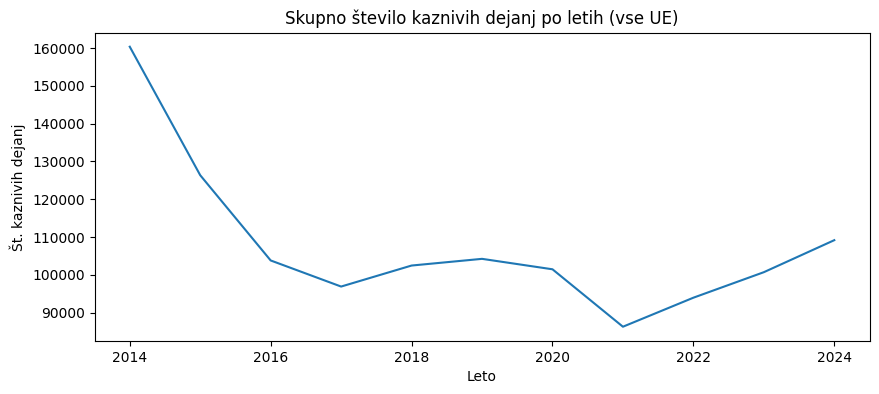

In [445]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_master, x="leto", y="st_kaznivih_dejanj",
             estimator="sum", errorbar=None)
plt.title("Skupno število kaznivih dejanj po letih (vse UE)")
plt.xlabel("Leto"); plt.ylabel("Št. kaznivih dejanj")
plt.show()

 Po padcu med 2014–2017 sledi nihanje in ponoven dvig po 2021; trend ni strogo monotoni, zato je smiselno modelirati časovni vpliv. Razlog za upad leta 2020 in 2021 poznamo, in sicer je to pandemija covid-19. Ker je 2021 očiten outlier ga bomo iz nadaljne analize izvzeli.

## 3. 2. Top 10 UE po kaznivih dejanjih na 1000 prebivalcev (2024)

Da identificiramo najbolj izpostavljene UE na prebivalca

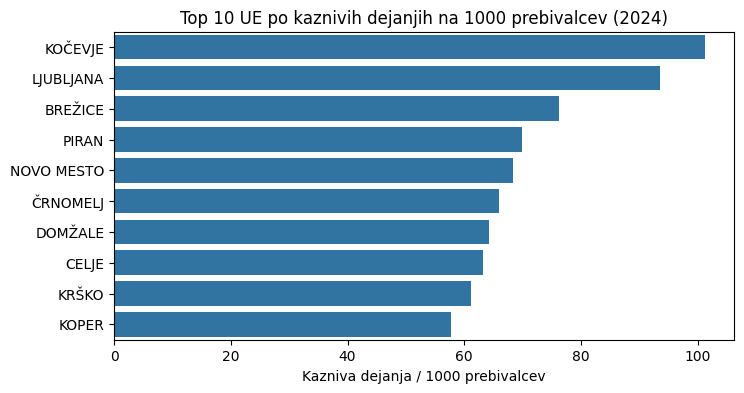

In [446]:
zadnje_leto = df_master["leto"].max()


top_rate = (df_master[df_master.leto == zadnje_leto]
            .sort_values("kriminaliteta_na_1000_preb", ascending=False)
            .head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=top_rate, y="Upravna_enota", x="kriminaliteta_na_1000_preb")


plt.title(f"Top 10 UE po kaznivih dejanjih na 1000 prebivalcev ({zadnje_leto})")
plt.xlabel("Kazniva dejanja / 1000 prebivalcev")
plt.ylabel("")
plt.show()

Nekaj UE močno izstopa (npr. Kočevje, Ljubljana) in je višje od ostalih; problem ni enakomerno porazdeljen.

## 3. 3. Tri upravne enote z največ in tri upravne neote z najmanj kaznivih dejanj na 1000 prebivalcev

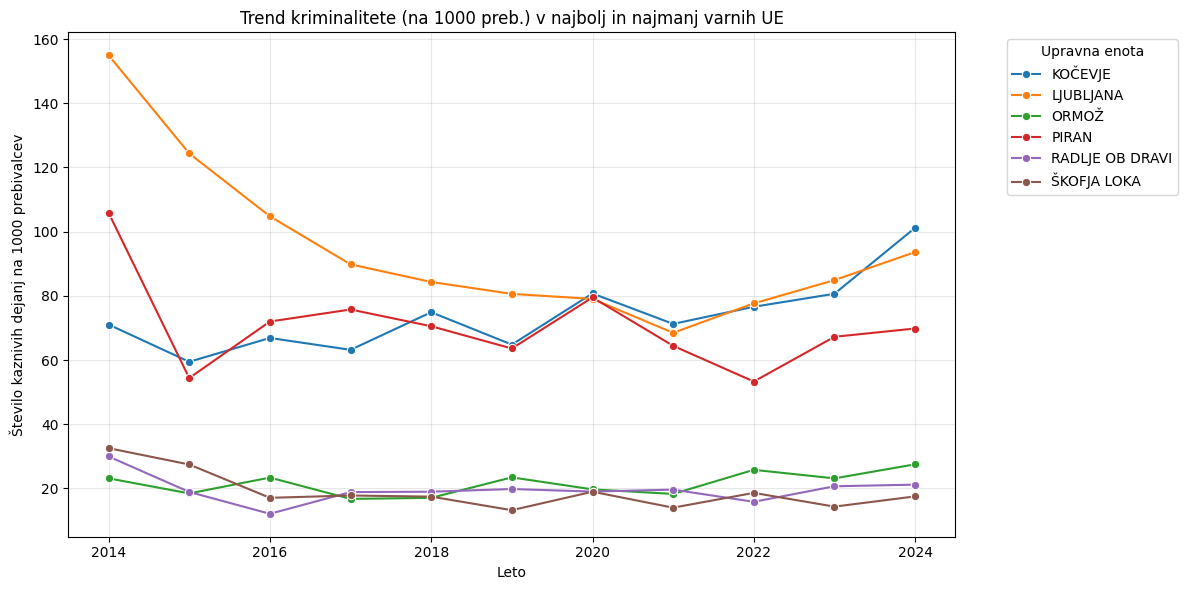

In [447]:
povprecje_kriminalitete = df_master.groupby('Upravna_enota')['kriminaliteta_na_1000_preb'].mean().sort_values()

najbolj_varne = povprecje_kriminalitete.head(3).index.tolist()
najbolj_nevarne = povprecje_kriminalitete.tail(3).index.tolist()
izbrane_ue = najbolj_varne + najbolj_nevarne

df_plot = df_master[df_master['Upravna_enota'].isin(izbrane_ue)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='leto', y='kriminaliteta_na_1000_preb', hue='Upravna_enota', marker='o')

plt.title('Trend kriminalitete (na 1000 preb.) v najbolj in najmanj varnih UE')
plt.ylabel('Število kaznivih dejanj na 1000 prebivalcev')
plt.xlabel('Leto')
plt.legend(title='Upravna enota', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visoko tvegane UE (Ljubljana, Kočevje, Piran) so po letu 2020 spet v porastu, Kočevje 2024 celo preseže Ljubljano (~101/1000 preb.). Nizko tvegane UE (Ormož, Radlje, Škofja Loka) ostajajo stabilno nizke (12–30/1000 preb.) z le manjšimi nihanji.

## 3. 4. Upravne enote z največjim porastom kriminalitete

TOP 5 UE z največjim trendom rasti kriminalitete (11 let):


,Upravna_enota,Trend_naklon,Skupna_sprememba
1,BREŽICE,2.897181,22.873136
15,KOČEVJE,2.605258,20.345788
30,NOVO MESTO,1.451390,13.951838
26,METLIKA,0.963671,11.119367
31,ORMOŽ,0.486969,3.823601



TOP 5 UE, kjer je varnost najbolj narasla (trend pada):


,Upravna_enota,Trend_naklon,Skupna_sprememba
54,ŠENTJUR PRI CELJU,-2.979226,-24.164068
6,GORNJA RADGONA,-3.579495,-17.048422
51,VRHNIKA,-5.133328,-41.138988
22,LJUBLJANA,-5.398095,-42.638516
11,IZOLA,-6.211980,-50.654162


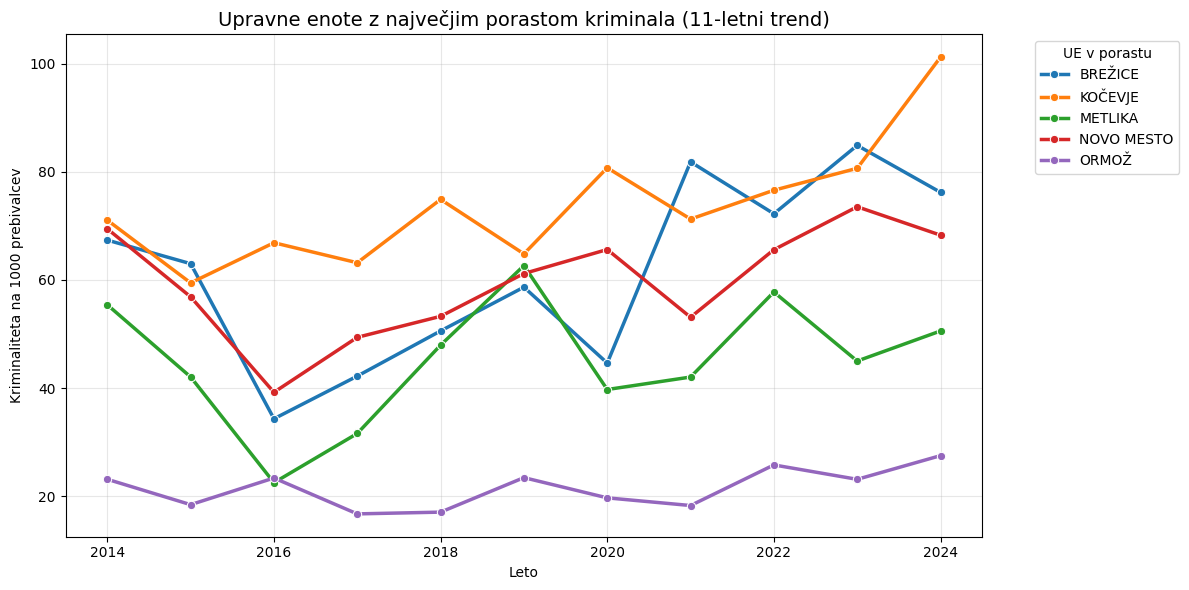

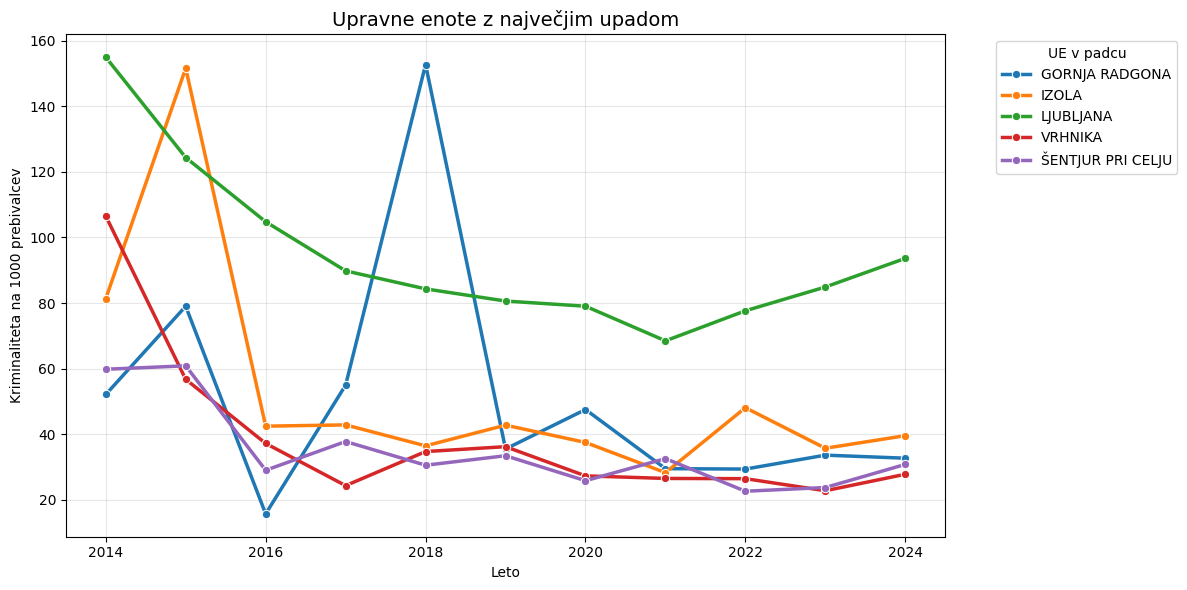

In [448]:
trend_rezultati = []


for ue in df_master['Upravna_enota'].unique():
    df_ue = df_master[df_master['Upravna_enota'] == ue]
    if len(df_ue) > 1:
        # Linregress vrne 'slope' (naklon).
        slope, intercept, r_value, p_value, std_err = linregress(df_ue['leto'], df_ue['kriminaliteta_na_1000_preb'])
        start_avg = df_ue.head(3)['kriminaliteta_na_1000_preb'].mean()
        end_avg = df_ue.tail(3)['kriminaliteta_na_1000_preb'].mean()
        diff = end_avg - start_avg

        trend_rezultati.append({
            'Upravna_enota': ue,
            'Trend_naklon': slope,
            'Skupna_sprememba': diff
        })

df_trend = pd.DataFrame(trend_rezultati).sort_values(by='Trend_naklon', ascending=False)

print("TOP 5 UE z največjim trendom rasti kriminalitete (11 let):")
display(df_trend.head(5))

print("\nTOP 5 UE, kjer je varnost najbolj narasla (trend pada):")
display(df_trend.tail(5))


najslabse_ue = df_trend.head(5)['Upravna_enota'].tolist()
df_plot_trend = df_master[df_master['Upravna_enota'].isin(najslabse_ue)]

najboljse_ue = df_trend.tail(5)['Upravna_enota'].tolist()
df_plot_trend2 = df_master[df_master['Upravna_enota'].isin(najboljse_ue)]


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot_trend,
    x='leto',
    y='kriminaliteta_na_1000_preb',
    hue='Upravna_enota',
    marker='o',
    linewidth=2.5
)

plt.title('Upravne enote z največjim porastom kriminala (11-letni trend)', fontsize=14)
plt.ylabel('Kriminaliteta na 1000 prebivalcev')
plt.xlabel('Leto')
plt.grid(True, alpha=0.3)
plt.legend(title='UE v porastu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot_trend2,
    x='leto',
    y='kriminaliteta_na_1000_preb',
    hue='Upravna_enota',
    marker='o',
    linewidth=2.5
)

plt.title('Upravne enote z največjim upadom', fontsize=14)
plt.ylabel('Kriminaliteta na 1000 prebivalcev')
plt.xlabel('Leto')
plt.grid(True, alpha=0.3)
plt.legend(title='UE v padcu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Vidni so največji relativni upadi: Ljubljana dolgoročno pade iz ~155 (2014) na ~68 (2021), a po 2021 spet zleze proti ~94; Gornja Radgona in Izola imata kratke skoke (2015/2018), vendar na dolgi rok padeta na ~30–40 kaznivih dejanj na 1000 prebivalcev. Vrhnika in Šentjur pri Celju se od 2014 stabilno spuščata iz 60–100 na ~23–33, z le manjšimi nihanji v zadnjih letih.

## 3. 5. Prikaz korelacij s kriminaliteto na 1000 prebivalcev

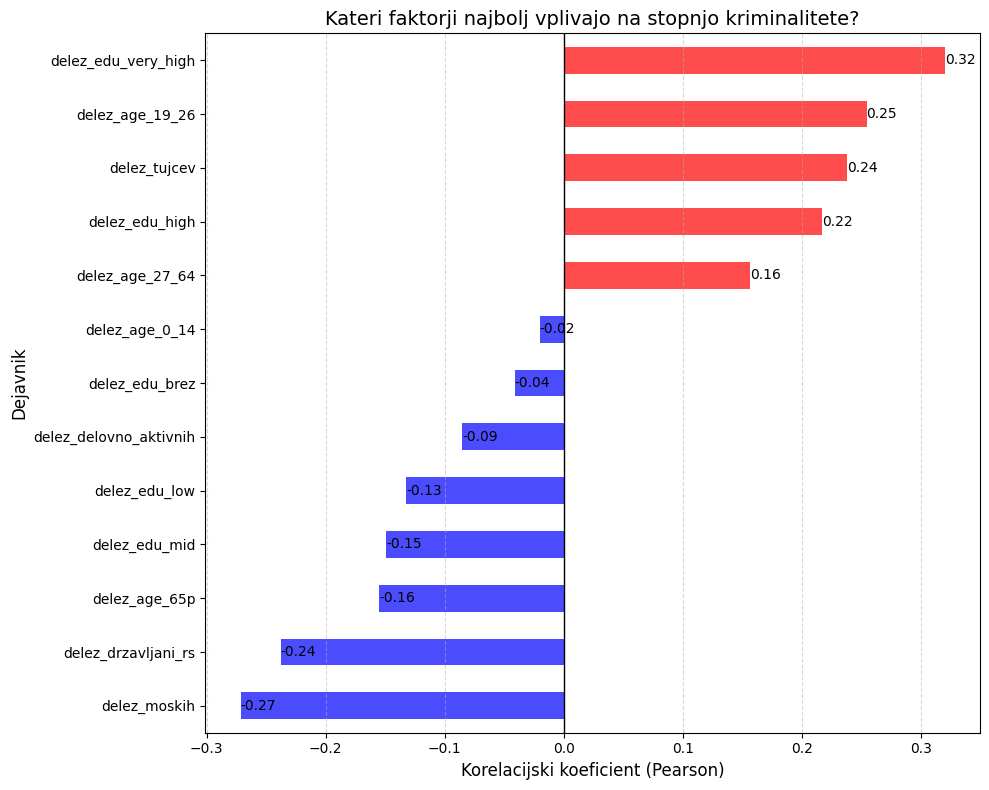

In [449]:
features_to_analyze = [
    'delez_moskih',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'delez_drzavljani_rs',
    'delez_edu_low',
    'delez_edu_mid',
    'delez_edu_high',
    'delez_edu_brez',
    'delez_edu_very_high',
    'delez_age_0_14',
    'delez_age_19_26',
    'delez_age_27_64',
    'delez_age_65p'
]

correlations = df_master[features_to_analyze + ['kriminaliteta_na_1000_preb']].corr()['kriminaliteta_na_1000_preb']
correlations = correlations.drop('kriminaliteta_na_1000_preb')
correlations = correlations.sort_values()

colors = ['red' if x > 0 else 'blue' for x in correlations]

plt.figure(figsize=(10, 8))

ax = correlations.plot(kind='barh', color=colors, alpha=0.7)

plt.title('Kateri faktorji najbolj vplivajo na stopnjo kriminalitete?', fontsize=14)
plt.xlabel('Korelacijski koeficient (Pearson)', fontsize=12)
plt.ylabel('Dejavnik', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Črta na sredini
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, value in enumerate(correlations):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

Najmočnejše pozitivne povezave s kriminaliteto imajo višji deleži najvišje izobraženih (0,32), starosti 19–26 (0,25) in tujcev (0,24), a vse korelacije ostajajo zmerne. Negativno izstopajo višji deleži moških (-0,27), državljanov RS (-0,24) ter starejših 65+ in srednje/nižjih izobraženih, kar kaže, da linearne zveze niso močne in jih je treba potrditi z modeli.

# 4. GRUČENJE


Za smiselno gručenje upravnih enot ne zadostuje linearno rangiranje po “varnosti”, temveč moramo hkrati upoštevati več razsežnosti, ki opisujejo njihov socioekonomski in urbani profil.

Kot osnovo vzamemo štiri ključne dimenzije: (1) varnost – kriminaliteta_na_1000_preb, (2) demografija – delež_tujcev, (3) ekonomija – delež_delovno_aktivnih, (4) urbanizacija – Prebivalstvo (velikost/stopnja urbanosti).

 K‑means na standardiziranih vrednostih nato sam prepozna naravne skupine, npr.

(A) “varno podeželje” z malo prebivalcev, malo tujcev in nizko kriminaliteto;

(B) “urbana središča” z več prebivalci in tujci, višjo zaposlenostjo ter praviloma višjo kriminaliteto;

(C) “problematična območja” z nižjo zaposlenostjo, a nesorazmerno višjo kriminaliteto. Tak pristop omogoča, da gruče odražajo dejanske strukturne razlike med območji, ne zgolj enodimenzionalne razlike v stopnji kriminalitete.

## 4. 1. Gručenje za vsa leta

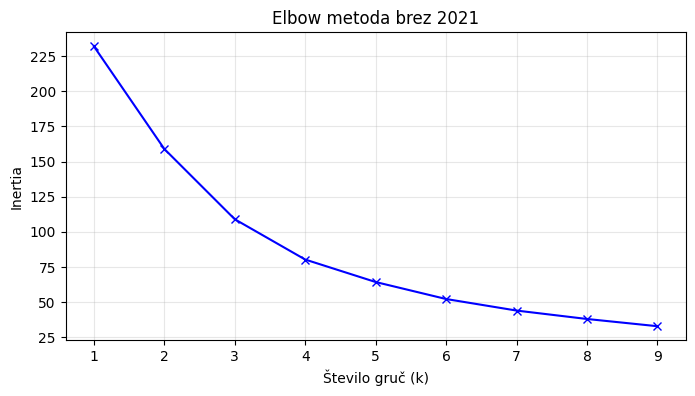

In [450]:
df_no2021 = df_master[df_master["leto"] != 2021].copy()

df_clustering = df_no2021.groupby("Upravna_enota")[[
    "kriminaliteta_na_1000_preb",
    "delez_tujcev",
    "delez_delovno_aktivnih",
    "Prebivalstvo"
]].mean()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)


inertia = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 10), inertia, "bx-")
plt.xlabel("Število gruč (k)")
plt.ylabel("Inertia")
plt.title("Elbow metoda brez 2021")
plt.grid(True, alpha=0.3)
plt.show()

Metoda komolca nam pokaže, da je res najbjboljše, da uporabljamo 3 gruče

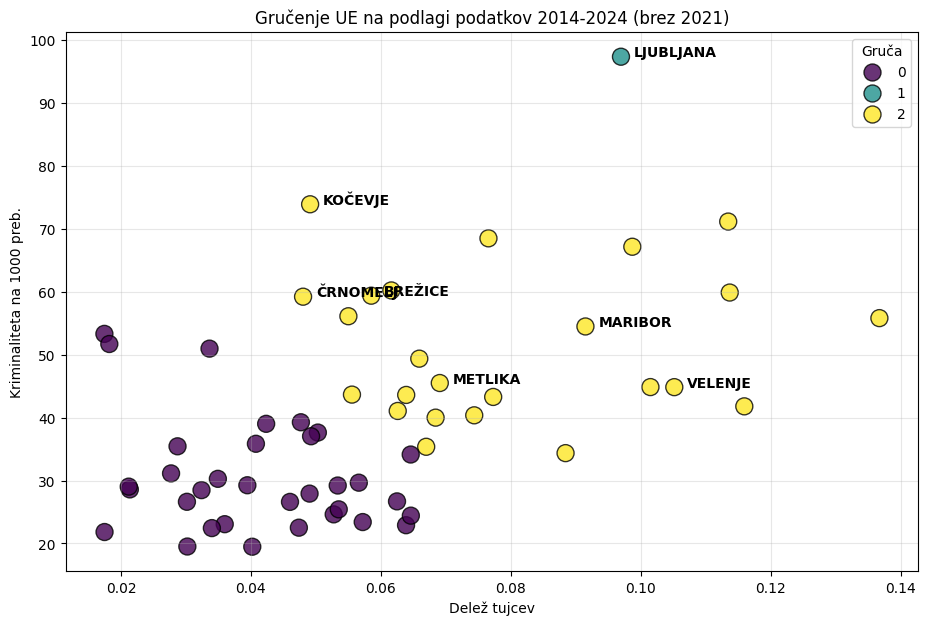

--- PROFILI GRUČ ---


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca,,,,
0,30.536451,0.041362,0.390850,23265.187879
2,51.428365,0.079921,0.413484,39733.866667
1,97.391752,0.096959,0.421721,365694.100000


In [451]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clustering['Gruca'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustering,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)


kljucne_ue = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'METLIKA', 'VELENJE', 'BREŽICE', 'ČRNOMELJ']

for ue in kljucne_ue:
    if ue in df_clustering.index:
        plt.text(
            df_clustering.loc[ue, 'delez_tujcev'] + 0.002,
            df_clustering.loc[ue, 'kriminaliteta_na_1000_preb'],
            ue,
            fontsize=10,
            fontweight='bold',
            color='black'
        )

plt.title('Gručenje UE na podlagi podatkov 2014-2024 (brez 2021)')
plt.xlabel('Delež tujcev')
plt.ylabel('Kriminaliteta na 1000 preb.')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

print("--- PROFILI GRUČ ---")
recent_profile = df_clustering.groupby('Gruca').mean().sort_values('kriminaliteta_na_1000_preb')
display(recent_profile)



Gručа 1 (turkizna, zgoraj desno): Ljubljana – samostojna kategorija z izrazito višjim deležem tujcev in najvišjo stopnjo kriminalitete (90+/1.000 preb.), kar odraža edinstven status metropole v slovenskem prostoru.

Gručа 2 (rumena, desna stran): urbana/industrijska središča – Maribor, Celje, Koper, Kranj, Brežice ipd. imajo višje deleže tujcev in povišano kriminaliteto. Kočevje izstopa kot anomalija: glede na relativno nižji delež tujcev ima nesorazmerno višjo kriminaliteto. (Lahko predvidevamo zakaj)

Gručа 0 (vijolična, levo spodaj): varna Slovenija – večina manjših UE z nizkimi deleži tujcev in nizko kriminaliteto; gre za stabilne, manj urbanizirane okolja.

## 4. 2. Gručenje pre-kovid podatkov

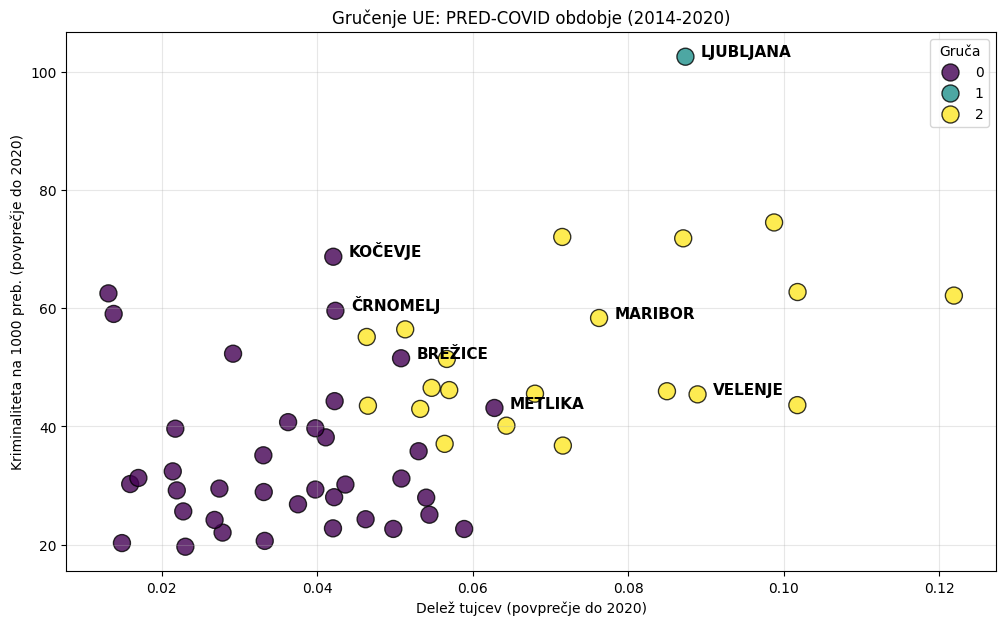

In [452]:
df_pre = df_master[df_master['leto'] < 2021].copy()

df_clustering_pre = df_pre.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'Prebivalstvo'
]].mean()

scaler_pre = StandardScaler()
X_pre_scaled = scaler_pre.fit_transform(df_clustering_pre)

kmeans_pre = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clustering_pre['Gruca'] = kmeans_pre.fit_predict(X_pre_scaled)


plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_clustering_pre,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

kljucna_mesta = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'METLIKA', 'VELENJE', 'BREŽICE', 'ČRNOMELJ']
for ime in kljucna_mesta:
    if ime in df_clustering_pre.index:
        plt.text(
            df_clustering_pre.loc[ime, 'delez_tujcev'] + 0.002,
            df_clustering_pre.loc[ime, 'kriminaliteta_na_1000_preb'],
            ime,
            fontsize=11,
            fontweight='bold'
        )

plt.title('Gručenje UE: PRED-COVID obdobje (2014-2020)')
plt.xlabel('Delež tujcev (povprečje do 2020)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje do 2020)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()


Copilot said: Pred covidom (2014–2020) je Ljubljana samostojno v
Pred covidom (2014–2020) je Ljubljana samostojno v najvišji gruči (Gruca 2): ima daleč najvišjo kriminaliteto in največji delež tujcev. Rumena gruča združuje urbana/povišana območja (npr. Koper, Maribor), z večjim deležem tujcev in srednje–visoko kriminaliteto. Vijolična gruča predstavlja večino UE z nizko kriminaliteto in nizkim deležem tujcev; Kočevje je tu izstopajoča vijolična točka z nadpovprečno kriminaliteto glede na svoj delež tujcev.

## 4. 3. Gručenje po letu 2021 (Po kovidu)

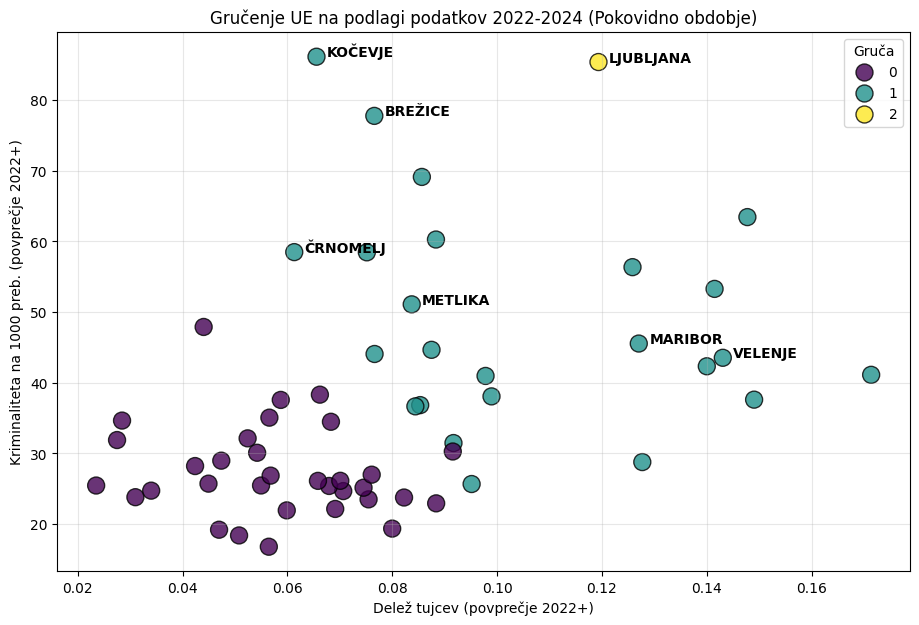

--- PROFILI GRUČ (2022-2024) ---


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca,,,,
0,27.406824,0.058087,0.410101,23394.828283
1,48.827043,0.105277,0.432769,40555.750000
2,85.378097,0.119332,0.441747,373297.000000


In [453]:
df_recent = df_master[df_master['leto'] >= 2022].copy()

df_clustering_recent = df_recent.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'Prebivalstvo'
]].mean()

scaler_recent = StandardScaler()
X_recent_scaled = scaler_recent.fit_transform(df_clustering_recent)

kmeans_recent = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clustering_recent['Gruca'] = kmeans_recent.fit_predict(X_recent_scaled)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustering_recent,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

kljucne_ue = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'METLIKA', 'VELENJE', 'BREŽICE', 'ČRNOMELJ']

for ue in kljucne_ue:
    if ue in df_clustering_recent.index:
        plt.text(
            df_clustering_recent.loc[ue, 'delez_tujcev'] + 0.002,
            df_clustering_recent.loc[ue, 'kriminaliteta_na_1000_preb'],
            ue,
            fontsize=10,
            fontweight='bold',
            color='black'
        )

plt.title('Gručenje UE na podlagi podatkov 2022-2024 (Pokovidno obdobje)')
plt.xlabel('Delež tujcev (povprečje 2022+)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje 2022+)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

print("--- PROFILI GRUČ (2022-2024) ---")
recent_profile = df_clustering_recent.groupby('Gruca').mean().sort_values('kriminaliteta_na_1000_preb')
display(recent_profile)



Na pokovidnem grafu (2022–2024) izstopa Kočevje z najvišjo kriminaliteto med “turkiznimi” (gr. 1), medtem ko Ljubljana ostaja samostojno v najvišji gruči (gr. 2) zaradi kombinacije visokega deleža tujcev in kriminalitete. Brežice se prav tako pomaknejo navzgor med bolj tveganimi, medtem ko večina ostalih UE ostaja v varnejši, vijolični gruči z nizkimi vrednostmi obeh kazalnikov.

## 4. 4. Analiza razlik

In [454]:
features = ["kriminaliteta_na_1000_preb", "delez_tujcev", "delez_delovno_aktivnih", "Prebivalstvo"]
dfs = {
    "ALL": df_clustering.copy(),
    "PRE": df_clustering_pre.copy(),
    "POST": df_clustering_recent.copy(),
}

def prepare(df):
    if df.index.name == "Upravna_enota":
        df = df.reset_index()
    elif "Upravna_enota" not in df.columns:
        df = df.reset_index().rename(columns={"index": "Upravna_enota"})
    else:
        df = df.reset_index(drop=True)
    return df

def remap_by_safety(df, cluster_col="Gruca"):
    # sort clusters by mean kriminaliteta (ascending) -> 0=varna, 1=srednja, 2=visoka
    order = df.groupby(cluster_col)["kriminaliteta_na_1000_preb"].mean().sort_values().index
    mapping = {old: new for new, old in enumerate(order)}
    df = df.copy()
    df[cluster_col + "_std"] = df[cluster_col].map(mapping)
    return df

profiles, z_profiles, importances = {}, {}, {}

# Remap in place
for tag, d in dfs.items():
    d = prepare(d)
    d = remap_by_safety(d, "Gruca")
    dfs[tag] = d
    ccol = "Gruca_std"

    # profili
    profiles[tag] = d.groupby(ccol)[features].agg(["mean", "median"])

    # z-score profili
    scaler = StandardScaler()
    Z = pd.DataFrame(scaler.fit_transform(d[features]), columns=features, index=d.index)
    z_profiles[tag] = Z.join(d[ccol]).groupby(ccol).mean()

    # RF importances
    X = d[features].fillna(d[features].median())
    y = d[ccol]
    rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")
    rf.fit(X, y)
    importances[tag] = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

# Prehodi PRE -> POST na standardiziranih etiketah
pre_df = dfs["PRE"]
post_df = dfs["POST"]

trans = pre_df[["Upravna_enota", "Gruca_std"]].merge(
    post_df[["Upravna_enota", "Gruca_std"]],
    on="Upravna_enota", how="inner", suffixes=("_pre", "_post")
)
trans["delta"] = trans["Gruca_std_post"] - trans["Gruca_std_pre"]
crosstab = pd.crosstab(trans["Gruca_std_pre"], trans["Gruca_std_post"])
moves = trans[trans["delta"] != 0].copy()
moves["Tip"] = np.where(moves["delta"] > 0, "POSLABŠANJE", "IZBOLJŠANJE")


In [455]:
print("=== Profili (mean/median) po gručah ===")
for tag, prof in profiles.items():
    print(f"\n[{tag}]"); display(prof)

=== Profili (mean/median) po gručah ===

[ALL]


kriminaliteta_na_1000_preb            delez_tujcev            \
                                mean     median         mean    median   
Gruca_std                                                                
0                          30.536451  28.599645     0.041362  0.040773   
1                          51.428365  47.450702     0.079921  0.071724   
2                          97.391752  97.391752     0.096959  0.096959   

          delez_delovno_aktivnih             Prebivalstvo            
                            mean    median           mean    median  
Gruca_std                                                            
0                       0.390850  0.400084   23265.187879   18270.7  
1                       0.413484  0.413968   39733.866667   27106.0  
2                       0.421721  0.421721  365694.100000  365694.1


[PRE]


kriminaliteta_na_1000_preb             delez_tujcev            \
                                mean      median         mean    median   
Gruca_std                                                                 
0                          34.456194   30.165905     0.035850  0.037537   
1                          51.906139   46.336511     0.072963  0.069773   
2                         102.540462  102.540462     0.087370  0.087370   

          delez_delovno_aktivnih             Prebivalstvo                 
                            mean    median           mean         median  
Gruca_std                                                                 
0                       0.381741  0.386767   22528.733591   18199.857143  
1                       0.411331  0.413749   43875.685714   33206.857143  
2                       0.413139  0.413139  362435.714286  362435.714286


[POST]


kriminaliteta_na_1000_preb            delez_tujcev            \
                                mean     median         mean    median   
Gruca_std                                                                
0                          27.406824  25.732787     0.058087  0.056781   
1                          48.827043  44.371035     0.105277  0.093397   
2                          85.378097  85.378097     0.119332  0.119332   

          delez_delovno_aktivnih             Prebivalstvo            
                            mean    median           mean    median  
Gruca_std                                                            
0                       0.410101  0.421361   23394.828283   17949.0  
1                       0.432769  0.434211   40555.750000   27708.5  
2                       0.441747  0.441747  373297.000000  373297.0

V vseh obdobjih se gruča 1 jasno loči kot “Ljubljana”: najvišja kriminaliteta (~ 95–103 na 1.000 preb.), največ tujcev (~ 0,09-0,12) in velikost mesta (~ 360–373k). Gruča 0 ostaja nizkotvegana (kriminaliteta ~ 27–35; manj tujcev; manjša populacija), gruča 2 pa je vmesna urbana skupina s srednjo kriminaliteto (~ 49–52) ter višjim deležem tujcev in večjo populacijo kot gruča 0.

In [456]:
print("\n=== Z-score profili (odklon od povprečja v obdobju) ===")
for tag, zprof in z_profiles.items():
    print(f"\n[{tag}]"); display(zprof)


=== Z-score profili (odklon od povprečja v obdobju) ===

[ALL]


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca_std,,,,
0,-0.610777,-0.625451,-0.347883,-0.257658
1,0.691613,0.800394,0.447624,0.075971
2,3.556944,1.430422,0.737146,6.679413



[PRE]


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca_std,,,,
0,-0.429273,-0.558154,-0.376897,-0.270277
1,0.612403,0.955437,0.661037,0.166103
2,3.635024,1.542978,0.724454,6.678195



[POST]


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca_std,,,,
0,-0.606424,-0.615609,-0.341833,-0.260586
1,0.710587,0.795789,0.438851,0.079900
2,2.957909,1.216142,0.748044,6.681749


Gruča 1 je v vseh obdobjih močno pozitivno odstopala (visoka kriminaliteta, več tujcev, nadpovprečna zaposlenost in izjemno velika populacija – tipično Ljubljana). Gruča 0 ima dosledno negativne z‑score (nizka kriminaliteta, malo tujcev, manjša populacija), gruča 2 pa zmerno pozitivne vrednosti kot vmesna urbana skupina.

In [457]:
print("\n=== Feature importances (RF) za ločevanje gruč ===")
for tag, imp in importances.items():
    print(f"\n[{tag}]"); display(imp)


=== Feature importances (RF) za ločevanje gruč ===

[ALL]


,0
kriminaliteta_na_1000_preb,0.493660
delez_tujcev,0.256108
Prebivalstvo,0.179916
delez_delovno_aktivnih,0.070316



[PRE]


,0
kriminaliteta_na_1000_preb,0.368166
delez_tujcev,0.331281
Prebivalstvo,0.197611
delez_delovno_aktivnih,0.102942



[POST]


,0
kriminaliteta_na_1000_preb,0.447205
delez_tujcev,0.280377
Prebivalstvo,0.201939
delez_delovno_aktivnih,0.070480


RandomForest pokaže, da je pri ločevanju gruč najmočnejša spremenljivka kriminaliteta_na_1000_preb (≈37–49% uteži). Sledi delež_tujcev (≈25–33%) in Prebivalstvo (≈18–20%), medtem ko delez_delovno_aktivnih dosledno prispeva najmanj (≈7–10%)

In [458]:

print(f"Št. premikov: {len(moves)}")
kr_pre = pre_df[["Upravna_enota", "kriminaliteta_na_1000_preb"]].rename(
    columns={"kriminaliteta_na_1000_preb": "krim_pre"}
)
kr_post = post_df[["Upravna_enota", "kriminaliteta_na_1000_preb"]].rename(
    columns={"kriminaliteta_na_1000_preb": "krim_post"}
)

moves_kr = moves.merge(kr_pre, on="Upravna_enota", how="left").merge(
    kr_post, on="Upravna_enota", how="left"
)
moves_kr["krim_diff"] = moves_kr["krim_post"] - moves_kr["krim_pre"]

display(
    moves_kr[
        ["Upravna_enota", "Gruca_std_pre", "Gruca_std_post", "Tip", "krim_pre", "krim_post", "krim_diff"]
    ].sort_values("krim_post", ascending=False)
)


Št. premikov: 4


,Upravna_enota,Gruca_std_pre,Gruca_std_post,Tip,krim_pre,krim_post,krim_diff
1,KOČEVJE,0,1,POSLABŠANJE,68.704177,86.130558,17.426380
0,BREŽICE,0,1,POSLABŠANJE,51.529900,77.760953,26.231053
3,ČRNOMELJ,0,1,POSLABŠANJE,59.560208,58.488588,-1.071621
2,METLIKA,0,1,POSLABŠANJE,43.120143,51.100414,7.980270


Dobili smo premike v 4 upravnih enotah
Kočevje, Brežice, Metlika, Črnomelj (0→1).
Iz manjših bolj varnih naselj v manj varne. Smiselno lahko sklepamo zakaj se je premik zgodil, saj je pri 3 od 4 upravnih enot precej povečana kriminaliteta na 1000 prebivalcev.

# 5. KLASIFIKACIJA

Ustvarimo kopijo dataframe-a, ki jo bomo uporabljali za klasifikacijo

In [459]:
df_klas = df_master.copy()

Izbrani feature-ji

Tukaj definiramo 16 značilk (features), ki jih bo model uporabil za napovedovanje razreda tveganja. Izbrali smo demografske podatke, deleže tujcev, starostno strukturo in stopnjo izobrazbe prebivalstva ter delež delovno aktivnih.

In [460]:
feature_klas = [
    "Prebivalstvo", "delez_moskih", "delez_zensk", "delez_tujcev",
    "delez_tujcev_m", "delez_tujcev_z", "delez_age_0_14", "delez_age_15_18", "delez_age_19_26",
    "delez_age_27_64", "delez_age_65p", "delez_edu_brez", "delez_edu_low",
    "delez_edu_mid", "delez_edu_high", "delez_edu_very_high", "delez_delovno_aktivnih"
]

print(f"Število features: {len(feature_klas)}")
print(f"Features:  {feature_klas}")

Število features: 17
Features:  ['Prebivalstvo', 'delez_moskih', 'delez_zensk', 'delez_tujcev', 'delez_tujcev_m', 'delez_tujcev_z', 'delez_age_0_14', 'delez_age_15_18', 'delez_age_19_26', 'delez_age_27_64', 'delez_age_65p', 'delez_edu_brez', 'delez_edu_low', 'delez_edu_mid', 'delez_edu_high', 'delez_edu_very_high', 'delez_delovno_aktivnih']


In [461]:
df_klas["razred_tveganja"] = pd.qcut(
    df_klas["kriminaliteta_na_1000_preb"],
    q=3,
    labels=["nizko", "srednje", "visoko"]
)

Podatke razdelimo časovno: leta 2014-2022 uporabimo za učenje, leto 2023 za validacijo in leto 2024 za končno testiranje. Takšna delitev prepreči "data leakage" - model se uči samo na preteklih podatkih.

In [462]:
df_train = df_klas[df_klas["leto"] <= 2022]. copy()
df_val = df_klas[df_klas["leto"] == 2023].copy()
df_test = df_klas[df_klas["leto"] == 2024].copy()

X_train, y_train = df_train[feature_klas], df_train["razred_tveganja"]
X_val, y_val = df_val[feature_klas], df_val["razred_tveganja"]
X_test, y_test = df_test[feature_klas], df_test["razred_tveganja"]

print(f"Učna množica (2014-2022): {len(df_train)} zapisov")
print(f"Validacijska množica (2023): {len(df_val)} zapisov")
print(f"Testna množica (2024): {len(df_test)} zapisov")

Učna množica (2014-2022): 522 zapisov
Validacijska množica (2023): 58 zapisov
Testna množica (2024): 58 zapisov


Skaliranje (standardizacija) podatkov je potrebno za Logistično regresijo, da vse značilke privedemo na primerljivo skalo. Uporabimo StandardScaler, ki podatke transformira na povprečje 0 in standardni odklon 1.

In [463]:
scaler = StandardScaler()
X_train_scaled = scaler. fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (522, 17)


Treniramo tri različne modele in jih ovrednotimo na validacijski množici (leto 2023). Primerjamo Accuracy in F1-macro metriki ter izberemo najboljši model za nadaljnjo uporabo.

In [464]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42)
}

results_val = {}
for name, model in models.items():
    if name == "LogisticRegression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    results_val[name] = {"accuracy": acc, "f1_macro": f1, "model": model}
    print(f"{name}:  Accuracy={acc:.3f}, F1-macro={f1:.3f}")


RandomForest:  Accuracy=0.638, F1-macro=0.623
GradientBoosting:  Accuracy=0.552, F1-macro=0.519
LogisticRegression:  Accuracy=0.603, F1-macro=0.585


In [465]:
best_model_name = max(results_val, key=lambda x: results_val[x]["f1_macro"])
print(f"\nNajboljši model: {best_model_name}")



Najboljši model: RandomForest


Out-of-Time (OOT) validacija simulira realno uporabo modela - za vsako leto od 2018 do 2023 treniramo model samo na preteklih podatkih in testiramo na tistem letu. To pokaže, kako stabilno model deluje skozi čas.

In [466]:
oot_results = []
for test_year in range(2018, 2024):
    train_data = df_klas[df_klas["leto"] < test_year]
    test_data = df_klas[df_klas["leto"] == test_year]

    X_tr, y_tr = train_data[feature_klas], train_data["razred_tveganja"]
    X_te, y_te = test_data[feature_klas], test_data["razred_tveganja"]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)

    oot_results.append({
        "test_year": test_year,
        "accuracy": accuracy_score(y_te, y_pred),
        "f1_macro": f1_score(y_te, y_pred, average="macro")
    })

df_oot = pd.DataFrame(oot_results)
print(df_oot.to_string(index=False))
print(f"\nPovprečna accuracy:  {df_oot['accuracy'].mean():.3f}")
print(f"Povprečni F1-macro: {df_oot['f1_macro'].mean():.3f}")


 test_year  accuracy  f1_macro
      2018  0.672414  0.673820
      2019  0.534483  0.539151
      2020  0.689655  0.695811
      2021  0.672414  0.664727
      2022  0.724138  0.698701
      2023  0.637931  0.623087

Povprečna accuracy:  0.655
Povprečni F1-macro: 0.649


Za končno napoved uporabimo vse podatke do leta 2023 za treniranje in napovemo razrede tveganja za leto 2024. Izpišemo podrobno poročilo o uspešnosti modela z metrikami precision, recall in F1-score za vsak razred.

In [467]:
df_final_train = df_klas[df_klas["leto"] < 2024]
X_final, y_final = df_final_train[feature_klas], df_final_train["razred_tveganja"]

final_model = RandomForestClassifier(n_estimators=100, random_state=123)
final_model. fit(X_final, y_final)
y_pred_2024 = final_model.predict(X_test)

print(f"Accuracy za 2024: {accuracy_score(y_test, y_pred_2024):.3f}")
print(f"F1-macro za 2024: {f1_score(y_test, y_pred_2024, average='macro'):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_2024))

Accuracy za 2024: 0.741
F1-macro za 2024: 0.737

Classification Report:
              precision    recall  f1-score   support

       nizko       0.72      0.86      0.78        21
     srednje       0.59      0.56      0.57        18
      visoko       0.94      0.79      0.86        19

    accuracy                           0.74        58
   macro avg       0.75      0.73      0.74        58
weighted avg       0.75      0.74      0.74        58



Poglejmo kako bi se model obnašal, če izpustimo leto 2021

In [468]:
df_final_train_no2021 = df_klas[(df_klas["leto"] < 2024) & (df_klas["leto"] != 2021)]
X_final_no2021, y_final_no2021 = df_final_train_no2021[feature_klas], df_final_train_no2021["razred_tveganja"]

model_no2021 = RandomForestClassifier(n_estimators=100, random_state=123)
model_no2021.fit(X_final_no2021, y_final_no2021)
y_pred_no2021 = model_no2021.predict(X_test)

acc_no2021 = accuracy_score(y_test, y_pred_no2021)
f1_no2021 = f1_score(y_test, y_pred_no2021, average='macro')

print(f"Accuracy {acc_no2021}")
print(f"F1-Macro {f1_no2021}")


Accuracy 0.7241379310344828
F1-Macro 0.7227513227513227


Accuracy je bolj ali manj enak, F1-Macro pa je za 0.04% boljši, kar pomeni, da leto 2021 ne kvari našega vzorca

Tukaj prikažemo napovedi za vsako upravno enoto posebej in označimo, ali je bila napoved pravilna ali napačna. To omogoča podrobno analizo, katere upravne enote model pravilno klasificira in kje dela napake.

In [469]:
df_test["napoved"] = y_pred_2024
df_test["pravilno"] = df_test["razred_tveganja"] == df_test["napoved"]

print("="*60)
print("NAPOVEDI PO UPRAVNIH ENOTAH (2024)")
print("="*60)
print(df_test[["Upravna_enota", "razred_tveganja", "napoved", "pravilno"]].to_string(index=False))

print(f"\nPravilnih napovedi: {df_test['pravilno'].sum()}/{len(df_test)}")

NAPOVEDI PO UPRAVNIH ENOTAH (2024)
     Upravna_enota razred_tveganja napoved  pravilno
        AJDOVŠČINA           nizko   nizko      True
           BREŽICE          visoko  visoko      True
             CELJE          visoko  visoko      True
          CERKNICA           nizko   nizko      True
           DOMŽALE          visoko srednje     False
         DRAVOGRAD           nizko   nizko      True
    GORNJA RADGONA         srednje srednje      True
         GROSUPLJE          visoko  visoko      True
          HRASTNIK           nizko srednje     False
            IDRIJA           nizko   nizko      True
  ILIRSKA BISTRICA           nizko   nizko      True
             IZOLA         srednje srednje      True
          JESENICE           nizko srednje     False
            KAMNIK         srednje srednje      True
             KOPER          visoko  visoko      True
           KOČEVJE          visoko  visoko      True
             KRANJ          visoko srednje     False
           

## 5. 2. Vizualizacija klasifikacije

In [470]:
importances = pd.DataFrame({
    "feature": feature_klas,
    "importance":  final_model.feature_importances_
}).sort_values("importance", ascending=True)

# Analiza napak
df_errors = df_test[df_test["pravilno"] == False]
error_summary = df_test.groupby("razred_tveganja")["pravilno"].agg(["sum", "count"])
error_summary["accuracy"] = error_summary["sum"] / error_summary["count"]

print("Podatki za vizualizacijo pripravljeni!")
print(f"Število napak: {len(df_errors)}")

Podatki za vizualizacijo pripravljeni!
Število napak: 15


/tmp/ipython-input-2033890502.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_summary = df_test.groupby("razred_tveganja")["pravilno"].agg(["sum", "count"])


#### 5. 2. 1. Matrika zmede

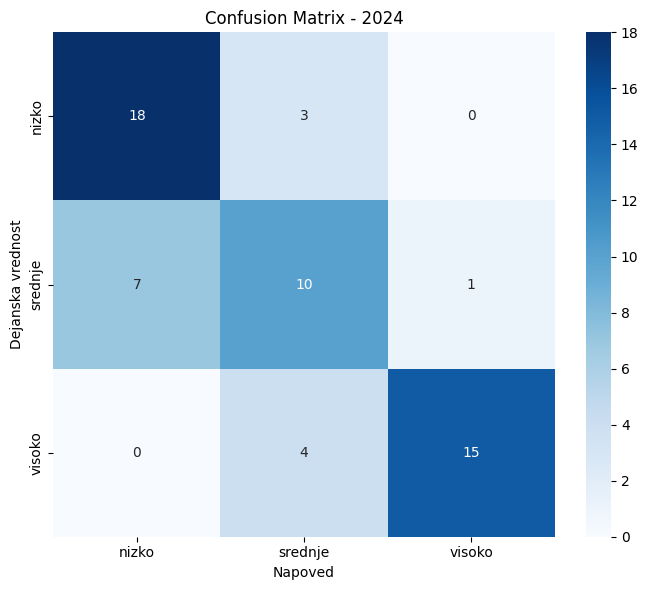

In [471]:
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_2024, labels=["nizko", "srednje", "visoko"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["nizko", "srednje", "visoko"],
            yticklabels=["nizko", "srednje", "visoko"])
plt.xlabel("Napoved")
plt.ylabel("Dejanska vrednost")
plt.title("Confusion Matrix - 2024")
plt.tight_layout()
plt.show()

#### 5. 2. 2. Pomembnost značilnic

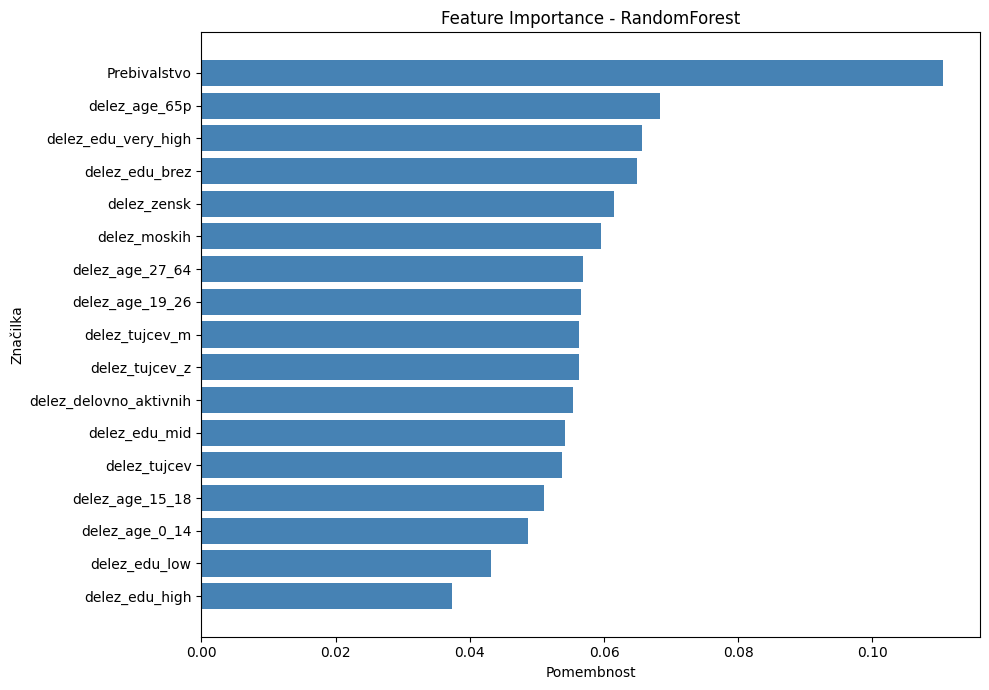

TOP 5 najpomembnejših značilk:
            feature  importance
        delez_zensk    0.061491
     delez_edu_brez    0.064866
delez_edu_very_high    0.065675
      delez_age_65p    0.068388
       Prebivalstvo    0.110497


In [472]:

plt.figure(figsize=(10, 7))
plt.barh(importances["feature"], importances["importance"], color="steelblue")
plt.xlabel("Pomembnost")
plt.ylabel("Značilka")
plt.title("Feature Importance - RandomForest")
plt.tight_layout()
plt.show()

print("TOP 5 najpomembnejših značilk:")
print(importances.tail(5).to_string(index=False))

#### 5. 2. 3. Točnost po razredih

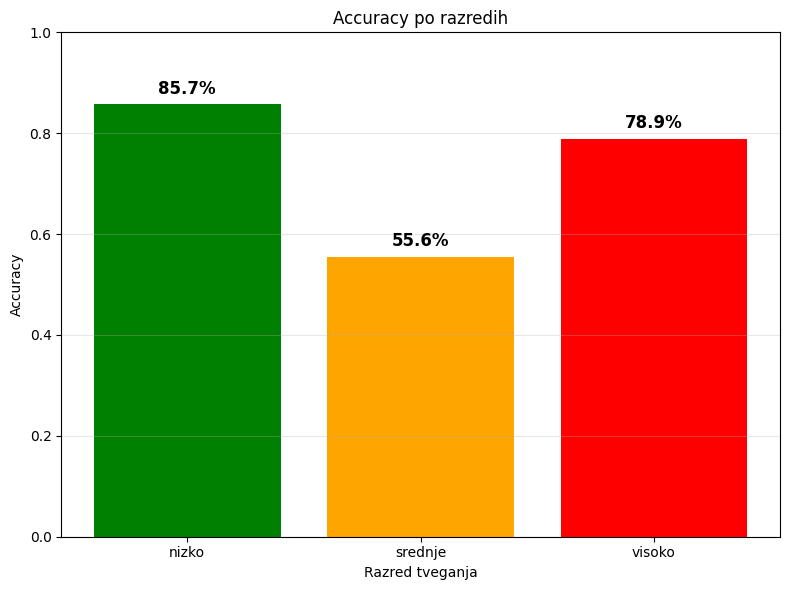


Accuracy po razredih:
  nizko: 85.7%
  srednje: 55.6%
  visoko: 78.9%


In [473]:

plt. figure(figsize=(8, 6))
plt.bar(error_summary. index, error_summary["accuracy"], color=["green", "orange", "red"])
plt.xlabel("Razred tveganja")
plt.ylabel("Accuracy")
plt.title("Accuracy po razredih")
plt.ylim(0, 1)
for i, v in enumerate(error_summary["accuracy"]):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAccuracy po razredih:")
for razred, acc in error_summary["accuracy"].items():
    print(f"  {razred}: {acc*100:.1f}%")

#### 5. 2. 4. Analiza napak

In [474]:
print(f"\nSkupno napačnih napovedi: {len(df_errors)}/{len(df_test)} ({len(df_errors)/len(df_test)*100:.1f}%)")

print("\nNapačne napovedi:")
print(df_errors[["Upravna_enota", "razred_tveganja", "napoved", "kriminaliteta_na_1000_preb"]].to_string(index=False))


Skupno napačnih napovedi: 15/58 (25.9%)

Napačne napovedi:
    Upravna_enota razred_tveganja napoved  kriminaliteta_na_1000_preb
          DOMŽALE          visoko srednje                   64.285714
         HRASTNIK           nizko srednje                   22.770826
         JESENICE           nizko srednje                   28.329957
            KRANJ          visoko srednje                   52.142415
           LITIJA         srednje   nizko                   30.779185
          LOGATEC         srednje   nizko                   38.420562
          PESNICA           nizko srednje                   23.159285
          RIBNICA         srednje   nizko                   36.405168
             RUŠE         srednje   nizko                   32.457284
           SEŽANA         srednje  visoko                   36.156147
SLOVENSKE KONJICE         srednje   nizko                   33.145998
          TREBNJE          visoko srednje                   48.448751
          VELENJE          vis

#### 5. 2. 5. Povzetek

In [475]:
print(f"Model: RandomForest (n_estimators=100)")
print(f"Število features: {len(feature_klas)}")
print(f"")
print(f"Accuracy 2024: {accuracy_score(y_test, y_pred_2024)*100:.1f}%")
print(f"F1-macro 2024: {f1_score(y_test, y_pred_2024, average='macro')*100:.1f}%")
print(f"Povprečna OOT accuracy: {df_oot['accuracy'].mean()*100:.1f}%")
print(f"")
print(f"Pravilnih napovedi: {df_test['pravilno'].sum()}/{len(df_test)}")
print(f"Napačnih napovedi: {len(df_errors)}/{len(df_test)}")
print(f"")
print(f"Najboljša značilka: {importances.iloc[-1]['feature']}")
print(importances.iloc[-1]['importance'])


Model: RandomForest (n_estimators=100)
Število features: 17

Accuracy 2024: 74.1%
F1-macro 2024: 73.7%
Povprečna OOT accuracy: 65.5%

Pravilnih napovedi: 43/58
Napačnih napovedi: 15/58

Najboljša značilka: Prebivalstvo
0.11049749387251447


# 6. REGRESIJA


Napovedovanje kriminalitete po upravnih enotah je glavni namen te analize in tukaj bomo z regresijo napovedovali kriminaliteto na 1000 prebivalcev za leto 2024 na tri različne načine, da vidimo kako lahko najboljše napovemo.
Prvi način je napoved izključno iz demografskih podatkov, drugi je samo iz zgodovine kriminalitete po upravnih enotah, tretji je pa kombinacija obeh, torej demografska slika in pa kriminaliteta preteklega leta.

In [476]:
df_reg = df_master.copy(deep=True)

## 6. 1. Napoved na podlagi demografske slike

Izberemo značilnice in razdelimo podatke

In [477]:
features_reg = [
    'delez_tujcev', 'delez_moskih',
    'delez_age_0_14','delez_age_15_18', 'delez_age_19_26',
    'delez_age_27_64', 'delez_age_65p',
    'delez_edu_brez', 'delez_edu_low', 'delez_edu_mid',
    'delez_edu_high', 'delez_edu_very_high',
    'delez_delovno_aktivnih'
]

X_train = df_reg.loc[df_reg['leto'] < 2024, features_reg].fillna(0)
y_train = df_reg.loc[df_reg['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test = df_reg.loc[df_reg['leto'] == 2024, features_reg].fillna(0)
y_test = df_reg.loc[df_reg['leto'] == 2024, 'kriminaliteta_na_1000_preb']
ue_names = df_reg.loc[df_reg['leto'] == 2024, 'Upravna_enota']

### 6. 1. 1. Izbira in učenje modelov

In [478]:
# linearna regresija
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# random forest
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

from xgboost import XGBRegressor
#xgboost
xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_reg.fit(X_train, y_train)
y_pred_xgb = xgb_reg.predict(X_test)

# Izračun metrik
models_results = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'R2': r2_score(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr))
    },
    'Random Forest': {
        'MAE':  mean_absolute_error(y_test, y_pred_rf),
        'R2': r2_score(y_test, y_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf))
    },
    'XGBoost': {
        'MAE': mean_absolute_error(y_test, y_pred_xgb),
        'R2': r2_score(y_test, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    }
}

for i, (model_name, metrics) in enumerate(models_results. items(), 1):
    print(f"{i}. {model_name:20s} | MAE = {metrics['MAE']: 5.2f} | "
          f"R² = {metrics['R2']: 6.2%} | RMSE = {metrics['RMSE']:5.2f}")

# Najboljši model
best_model = max(models_results, key=lambda x: models_results[x]['R2'])
best_r2 = models_results[best_model]['R2']

1. Linear Regression    | MAE =  11.52 | R² =  12.29% | RMSE = 16.97
2. Random Forest        | MAE =  7.72 | R² =  64.91% | RMSE = 10.73
3. XGBoost              | MAE =  7.39 | R² =  66.69% | RMSE = 10.46


### 6. 1. 2. Primerjava modelov

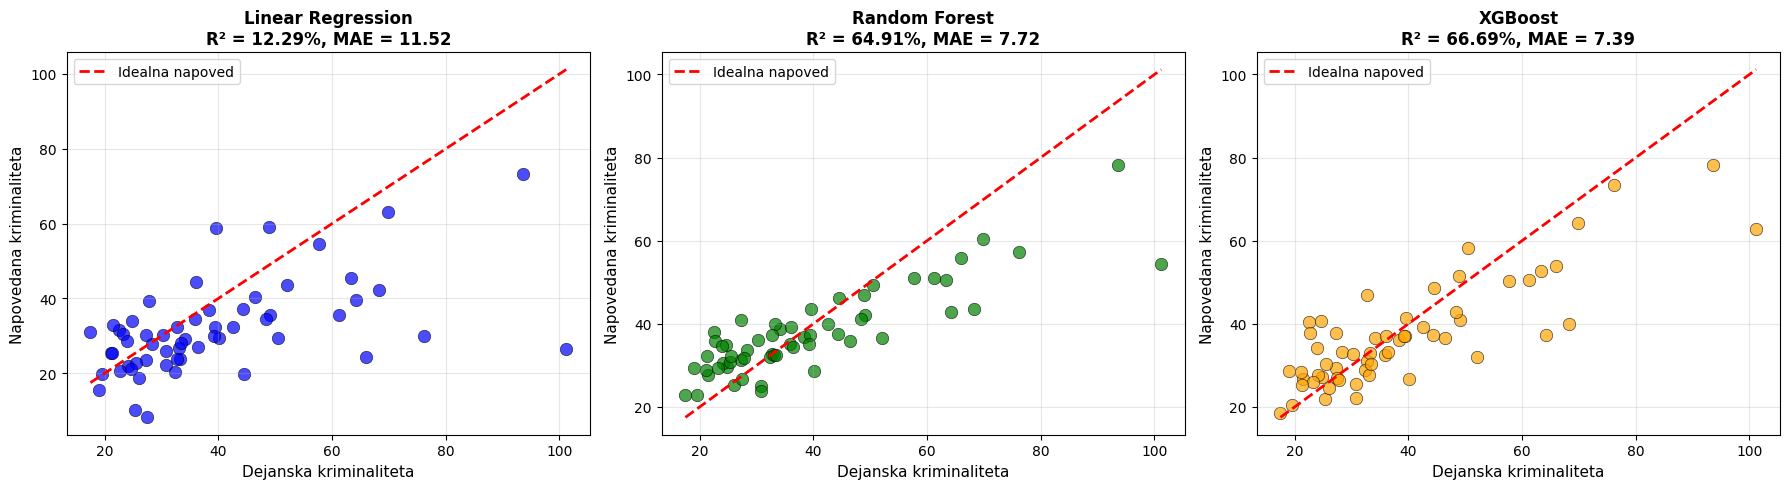

In [479]:
fig, axes = plt. subplots(1, 3, figsize=(18, 5))

predictions = [
    ('Linear Regression', y_pred_lr, 'blue'),
    ('Random Forest', y_pred_rf, 'green'),
    ('XGBoost', y_pred_xgb, 'orange')
]

for ax, (name, y_pred, color) in zip(axes, predictions):
    ax.scatter(y_test, y_pred, alpha=0.7, color=color, s=80, edgecolors='black', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Idealna napoved')

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    ax.set_xlabel('Dejanska kriminaliteta', fontsize=11)
    ax.set_ylabel('Napovedana kriminaliteta', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.2%}, MAE = {mae:.2f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regresija_primerjava_modeli.png', dpi=150)
plt.show()

## 6. 2. Napoved izključno glede na preteklo kriminaliteto

In [480]:
df_history = df_reg.copy()

df_history = df_history.sort_values(['Upravna_enota', 'leto'])
df_history['kriminal_LANI'] = df_history.groupby('Upravna_enota')['kriminaliteta_na_1000_preb'].shift(1)

# Odstranimo prvo leto (2014), ker nima podatka za "lani"
df_history = df_history.dropna(subset=['kriminal_LANI'])

X_train_hist = df_history.loc[df_history['leto'] < 2024, ['kriminal_LANI']]
y_train_hist = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test_hist = df_history.loc[df_history['leto'] == 2024, ['kriminal_LANI']]
y_test_hist = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# 1. Linearna regresija
lr_hist = LinearRegression()
lr_hist.fit(X_train_hist, y_train_hist)
y_pred_lr_hist = lr_hist.predict(X_test_hist)

# 2. Random Forest
rf_hist = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_hist.fit(X_train_hist, y_train_hist)
y_pred_rf_hist = rf_hist.predict(X_test_hist)

# 3. XGBoost
xgb_hist = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbosity=0)
xgb_hist.fit(X_train_hist, y_train_hist)
y_pred_xgb_hist = xgb_hist.predict(X_test_hist)
y_pred_hist = lr_hist.predict(X_test_hist)
r2_hist = r2_score(y_test_hist, y_pred_hist)
mae_hist = mean_absolute_error(y_test_hist, y_pred_hist)

models_hist = {
    'Linear Regression': y_pred_lr_hist,
    'Random Forest': y_pred_rf_hist,
    'XGBoost':  y_pred_xgb_hist
}

for i, (name, y_pred) in enumerate(models_hist.items(), 1):
    r2 = r2_score(y_test_hist, y_pred)
    mae = mean_absolute_error(y_test_hist, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_hist, y_pred))
    print(f"{i}. {name:20s} | MAE = {mae:5.2f} | R² = {r2:6.2%} | RMSE = {rmse:5.2f}")


1. Linear Regression    | MAE =  7.58 | R² = 64.69% | RMSE = 10.77
2. Random Forest        | MAE =  8.07 | R² = 58.40% | RMSE = 11.69
3. XGBoost              | MAE =  7.11 | R² = 66.87% | RMSE = 10.43


### 6. 2. 2. Primerjava modelov

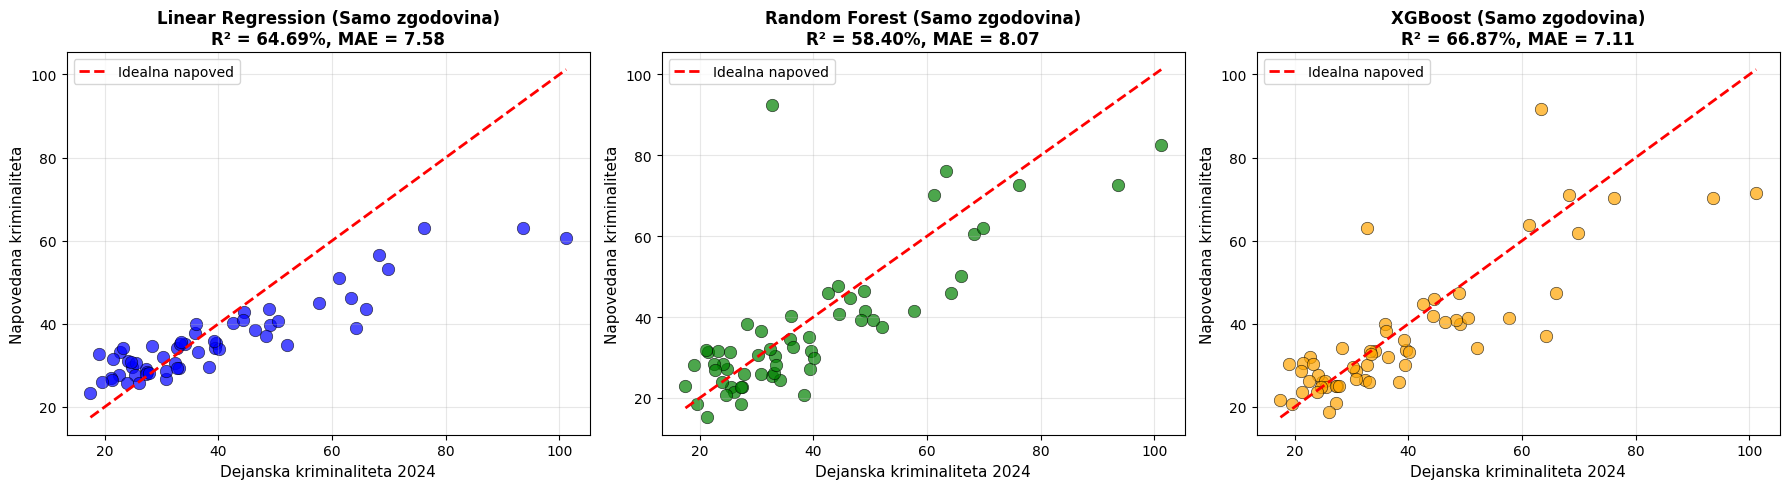

In [481]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictions_hist = [
    ('Linear Regression', y_pred_lr_hist, 'blue'),
    ('Random Forest', y_pred_rf_hist, 'green'),
    ('XGBoost', y_pred_xgb_hist, 'orange')
]

for ax, (name, y_pred, color) in zip(axes, predictions_hist):
    ax.scatter(y_test_hist, y_pred, alpha=0.7, color=color, s=80, edgecolors='black', linewidth=0.5)
    ax.plot([y_test_hist.min(), y_test_hist.max()], [y_test_hist.min(), y_test_hist.max()],
            'r--', lw=2, label='Idealna napoved')

    r2 = r2_score(y_test_hist, y_pred)
    mae = mean_absolute_error(y_test_hist, y_pred)

    ax.set_xlabel('Dejanska kriminaliteta 2024', fontsize=11)
    ax.set_ylabel('Napovedana kriminaliteta', fontsize=11)
    ax.set_title(f'{name} (Samo zgodovina)\nR² = {r2:.2%}, MAE = {mae:.2f}',
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regresija_samo_zgodovina.png', dpi=150)
plt.show()

## 6. 3. Napoved s kombinacijo demografije in preteklosti

In [482]:
features_both = [
    'delez_tujcev', 'delez_moskih',
    'delez_age_0_14','delez_age_15_18', 'delez_age_19_26',
    'delez_age_27_64', 'delez_age_65p',
    'delez_edu_brez', 'delez_edu_low', 'delez_edu_mid',
    'delez_edu_high', 'delez_edu_very_high',
    'delez_delovno_aktivnih', "kriminal_LANI"
]

X_train = df_history.loc[df_history['leto'] < 2024, features_both]
y_train = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test = df_history.loc[df_history['leto'] == 2024, features_both]
y_test = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']
ue_test = df_history.loc[df_history['leto'] == 2024, 'Upravna_enota']

# 1. Linearna regresija
lr_both = LinearRegression()
lr_both.fit(X_train, y_train)
y_pred_lr_both = lr_both.predict(X_test)

# 2. Random Forest
rf_both = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_both.fit(X_train, y_train)
y_pred_rf_both = rf_both.predict(X_test)

# 3. XGBoost
xgb_both = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                        random_state=42, n_jobs=-1, verbosity=0)
xgb_both.fit(X_train, y_train)
y_pred_xgb_both = xgb_both.predict(X_test)



models_both = {
    'Linear Regression': y_pred_lr_both,
    'Random Forest': y_pred_rf_both,
    'XGBoost': y_pred_xgb_both
}

for i, (name, y_pred) in enumerate(models_both.items(), 1):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{i}. {name:20s} | MAE = {mae:5.2f} | R² = {r2:6.2%} | RMSE = {rmse:5.2f}")



1. Linear Regression    | MAE =  7.60 | R² = 64.55% | RMSE = 10.79
2. Random Forest        | MAE =  5.18 | R² = 84.55% | RMSE =  7.12
3. XGBoost              | MAE =  6.16 | R² = 77.88% | RMSE =  8.52


### 6. 3. 2. Primerjava modelov

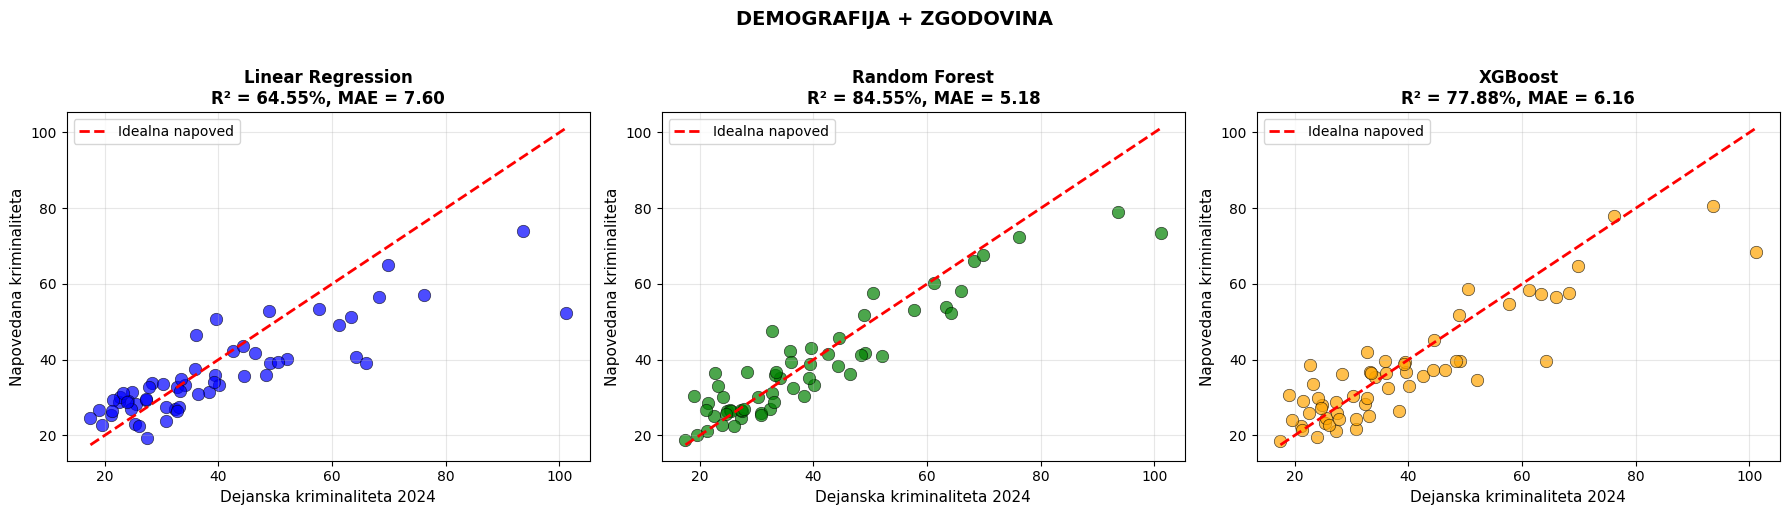

In [483]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictions_both = [
    ('Linear Regression', y_pred_lr_both, 'blue'),
    ('Random Forest', y_pred_rf_both, 'green'),
    ('XGBoost', y_pred_xgb_both, 'orange')
]

for ax, (name, y_pred, color) in zip(axes, predictions_both):
    ax.scatter(y_test, y_pred, alpha=0.7, color=color, s=80, edgecolors='black', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Idealna napoved')

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    ax.set_xlabel('Dejanska kriminaliteta 2024', fontsize=11)
    ax.set_ylabel('Napovedana kriminaliteta', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.2%}, MAE = {mae:.2f}',
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('DEMOGRAFIJA + ZGODOVINA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regresija_demografija_zgodovina.png', dpi=150)
plt.show()

## 6. 4. Napoved, če odstranimo 2021 (osamelec)

Graf v 3. 1. točki je pokazal, da je leto 2021 outlier, zato bomo poskusili napovedati kriminaliteto, brez leta 2021, da vidimo, če res vpliva na napoved

In [484]:
# Odstrani leto 2021
X_train_no2021 = df_history.loc[(df_history['leto'] < 2024) & (df_history['leto'] != 2021), features_both]
y_train_no2021 = df_history.loc[(df_history['leto'] < 2024) & (df_history['leto'] != 2021), 'kriminaliteta_na_1000_preb']

X_test_no2021 = df_history.loc[df_history['leto'] == 2024, features_both]
y_test_no2021 = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# 1. Linearna regresija
lr_no2021 = LinearRegression()
lr_no2021.fit(X_train_no2021, y_train_no2021)
y_pred_lr_no2021 = lr_no2021.predict(X_test_no2021)

# 2. Random Forest
rf_no2021 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_no2021.fit(X_train_no2021, y_train_no2021)
y_pred_rf_no2021 = rf_no2021.predict(X_test_no2021)

# 3. XGBoost
xgb_no2021 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_no2021.fit(X_train_no2021, y_train_no2021)
y_pred_xgb_no2021 = xgb_no2021.predict(X_test_no2021)

models_no2021 = {
    'Linear Regression': y_pred_lr_no2021,
    'Random Forest': y_pred_rf_no2021,
    'XGBoost': y_pred_xgb_no2021
}

for i, (name, y_pred) in enumerate(models_no2021.items(), 1):
    r2 = r2_score(y_test_no2021, y_pred)
    mae = mean_absolute_error(y_test_no2021, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_no2021, y_pred))
    print(f"{i}. {name:20s} | MAE = {mae:5.2f} | R² = {r2:6.2%} | RMSE = {rmse:5.2f}")

1. Linear Regression    | MAE =  7.83 | R² = 63.20% | RMSE = 10.99
2. Random Forest        | MAE =  5.09 | R² = 85.47% | RMSE =  6.91
3. XGBoost              | MAE =  5.88 | R² = 80.82% | RMSE =  7.93


### 6. 4. 2. Primerjava napovedi z ali brez leta 2021

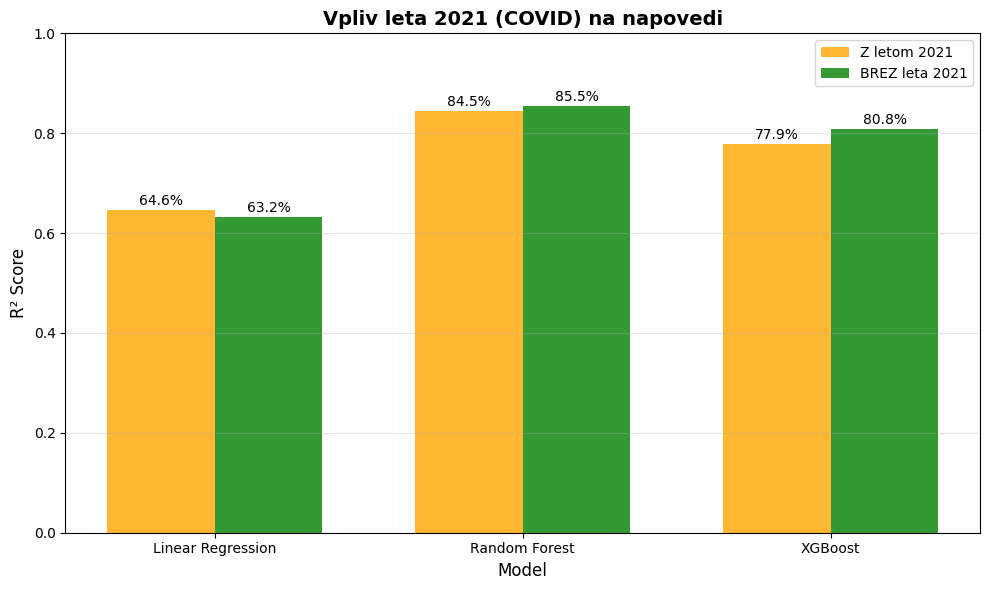

In [485]:
comparison = {
    'Linear Regression': {
        'Z 2021': r2_score(y_test, y_pred_lr_both),
        'BREZ 2021': r2_score(y_test_no2021, y_pred_lr_no2021)
    },
    'Random Forest': {
        'Z 2021':  r2_score(y_test, y_pred_rf_both),
        'BREZ 2021': r2_score(y_test_no2021, y_pred_rf_no2021)
    },
    'XGBoost': {
        'Z 2021': r2_score(y_test, y_pred_xgb_both),
        'BREZ 2021': r2_score(y_test_no2021, y_pred_xgb_no2021)
    }
}

# Vizualizacija
models_list = list(comparison.keys())
z_2021 = [comparison[m]['Z 2021'] for m in models_list]
brez_2021 = [comparison[m]['BREZ 2021'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, z_2021, width, label='Z letom 2021', color='orange', alpha=0.8)
bars2 = plt.bar(x + width/2, brez_2021, width, label='BREZ leta 2021', color='green', alpha=0.8)

plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Vpliv leta 2021 (COVID) na napovedi', fontsize=14, fontweight='bold')
plt.xticks(x, models_list)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Dodaj vrednosti
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('regresija_vpliv_2021.png', dpi=150)
plt.show()

## 6. 5. Napoved glede na bližnjo preteklost

In [486]:
# Samo zadnji 2 leti (2022, 2023)
X_train_recent = df_history. loc[df_history['leto']. isin([2022, 2023]), features_both]
y_train_recent = df_history.loc[df_history['leto'].isin([2022, 2023]), 'kriminaliteta_na_1000_preb']

X_test_recent = df_history.loc[df_history['leto'] == 2024, features_both]
y_test_recent = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# 1. Linearna regresija
lr_recent = LinearRegression()
lr_recent.fit(X_train_recent, y_train_recent)
y_pred_lr_recent = lr_recent.predict(X_test_recent)

# 2. Random Forest
rf_recent = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_recent.fit(X_train_recent, y_train_recent)
y_pred_rf_recent = rf_recent.predict(X_test_recent)

# 3. XGBoost
xgb_recent = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_recent.fit(X_train_recent, y_train_recent)
y_pred_xgb_recent = xgb_recent.predict(X_test_recent)

models_recent = {
    'Linear Regression': y_pred_lr_recent,
    'Random Forest': y_pred_rf_recent,
    'XGBoost': y_pred_xgb_recent
}

for i, (name, y_pred) in enumerate(models_recent.items(), 1):
    r2 = r2_score(y_test_recent, y_pred)
    mae = mean_absolute_error(y_test_recent, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_recent, y_pred))
    print(f"{i}. {name:20s} | MAE = {mae:5.2f} | R² = {r2:6.2%} | RMSE = {rmse:5.2f}")

1. Linear Regression    | MAE =  5.50 | R² = 82.98% | RMSE =  7.48
2. Random Forest        | MAE =  5.07 | R² = 86.20% | RMSE =  6.73
3. XGBoost              | MAE =  5.67 | R² = 83.25% | RMSE =  7.42


### 6. 5. 2. Primerjava napovedi glede zadnji 2 leti ali zadnjih 10 let

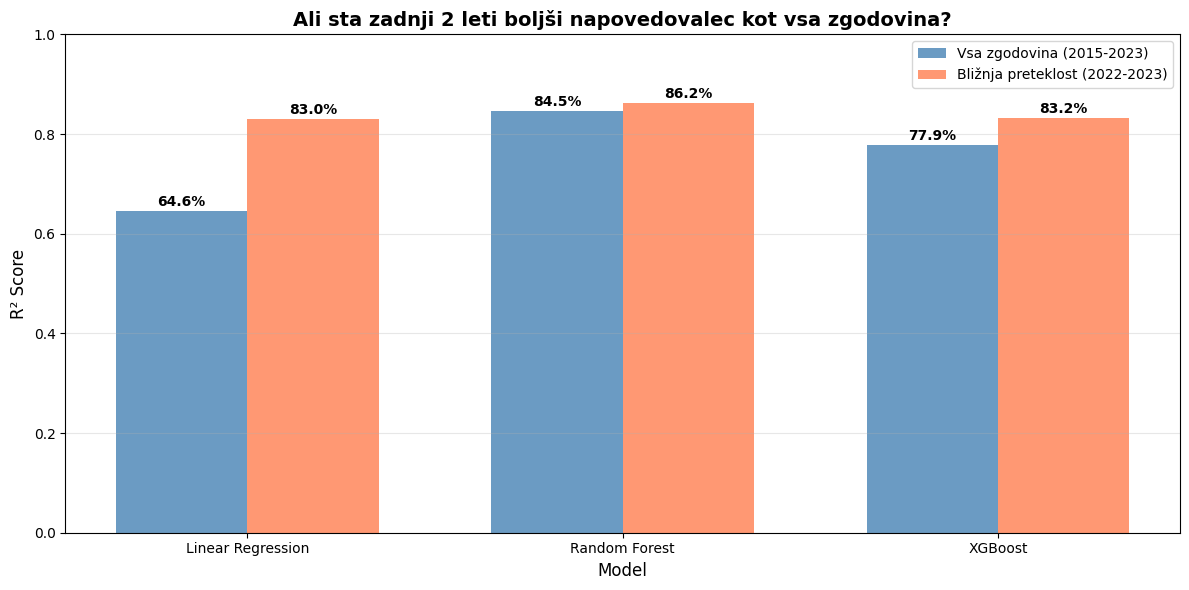

In [487]:
comparison_time = {
    'Linear Regression': {
        'Vsa zgodovina (2015-2023)': r2_score(y_test, y_pred_lr_both),
        'Bližnja preteklost (2022-2023)': r2_score(y_test_recent, y_pred_lr_recent)
    },
    'Random Forest': {
        'Vsa zgodovina (2015-2023)': r2_score(y_test, y_pred_rf_both),
        'Bližnja preteklost (2022-2023)': r2_score(y_test_recent, y_pred_rf_recent)
    },
    'XGBoost': {
        'Vsa zgodovina (2015-2023)': r2_score(y_test, y_pred_xgb_both),
        'Bližnja preteklost (2022-2023)': r2_score(y_test_recent, y_pred_xgb_recent)
    }
}

models_list = list(comparison_time.keys())
vsa = [comparison_time[m]['Vsa zgodovina (2015-2023)'] for m in models_list]
bliznja = [comparison_time[m]['Bližnja preteklost (2022-2023)'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, vsa, width, label='Vsa zgodovina (2015-2023)',
                color='steelblue', alpha=0.8)
bars2 = plt.bar(x + width/2, bliznja, width, label='Bližnja preteklost (2022-2023)',
                color='coral', alpha=0.8)

plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Ali sta zadnji 2 leti boljši napovedovalec kot vsa zgodovina?',
          fontsize=14, fontweight='bold')
plt.xticks(x, models_list)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Dodaj vrednosti
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('regresija_bliznja_preteklost.png', dpi=150)
plt.show()


Vsi trije modeli dosegajo BOLJŠE rezultate z bližnjo preteklostjo (2022-2023)
kot z vso zgodovino (2015-2023), kar kaže, da so novejši podatki bolj
relevantni za napoved 2024 - trendi v kriminaliteti se spreminjajo in stari
podatki motijo napovedi.  Največja izboljšava je pri Linear Regression
(+18.4pp), medtem ko je Random Forest že z vso zgodovino zelo dober (84.5%).

# 6. 6. Heterogeni ansambel

V tej celici testiramo **ansambel učenje** (ensemble learning), kjer kombiniramo več različnih modelov v en močnejši model

In [488]:
X_train = df_history. loc[df_history['leto'] < 2024, features_both]
y_train = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test = df_history.loc[df_history['leto'] == 2024, features_both]
y_test = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# Verzija 1: Enake uteži
estimators_v1 = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                         random_state=42, n_jobs=-1, verbosity=0))
]

ensemble_v1 = VotingRegressor(estimators=estimators_v1, weights=[1, 1, 1])
ensemble_v1.fit(X_train, y_train)
y_pred_v1 = ensemble_v1.predict(X_test)

# Verzija 2: Več uteži za RF in XGB (kompleksnejša modela)
ensemble_v2 = VotingRegressor(estimators=estimators_v1, weights=[1, 2, 2])
ensemble_v2.fit(X_train, y_train)
y_pred_v2 = ensemble_v2.predict(X_test)

# Verzija 3: Dominacija najboljšega (XGBoost)
ensemble_v3 = VotingRegressor(estimators=estimators_v1, weights=[1, 4, 2])
ensemble_v3.fit(X_train, y_train)
y_pred_v3 = ensemble_v3.predict(X_test)

all_models = {
    'Linear Regression (solo)': y_pred_lr_both,
    'Random Forest (solo)': y_pred_rf_both,
    'XGBoost (solo)': y_pred_xgb_both,
    'Ensemble (1: 1:1)': y_pred_v1,
    'Ensemble (1:2:2)': y_pred_v2,
    'Ensemble (1:4:2)': y_pred_v3
}

results = []
for name, y_pred in all_models.items():
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'R2':  r2, 'MAE':  mae, 'RMSE':  rmse})
    print(f"{name:30s} | MAE = {mae:5.2f} | R² = {r2:6.2%} | RMSE = {rmse:5.2f}")

best_model_name = max(all_models, key=lambda x:  r2_score(y_test, all_models[x]))
best_r2 = r2_score(y_test, all_models[best_model_name])
print(f"NAJBOLJŠI:  {best_model_name} (R² = {best_r2:.2%})")

Linear Regression (solo)       | MAE =  7.60 | R² = 64.55% | RMSE = 10.79
Random Forest (solo)           | MAE =  5.18 | R² = 84.55% | RMSE =  7.12
XGBoost (solo)                 | MAE =  6.16 | R² = 77.88% | RMSE =  8.52
Ensemble (1: 1:1)              | MAE =  5.79 | R² = 79.62% | RMSE =  8.18
Ensemble (1:2:2)               | MAE =  5.64 | R² = 81.17% | RMSE =  7.86
Ensemble (1:4:2)               | MAE =  5.46 | R² = 82.55% | RMSE =  7.57
NAJBOLJŠI:  Random Forest (solo) (R² = 84.55%)


Opazimo, da je vseeno najboljši model kar random forest sam po sebi

# 6. 7. Časovna vrsta ali  Walk-Forward validacija (Out-of-Time)


V tej celici testiramo **časovno stabilnost** modelov z walk-forward validacijo - najbolj realistično metodo za preverjanje napovedi časovnih vrst.



In [489]:
df_ts = df_history.sort_values('leto').copy()

test_years = [2019, 2020, 2021, 2022, 2023, 2024]

results_oot = []

for year in test_years:

    mask_train = df_ts['leto'] < year
    mask_test = df_ts['leto'] == year

    X_train_fold = df_ts. loc[mask_train, features_both]
    y_train_fold = df_ts.loc[mask_train, 'kriminaliteta_na_1000_preb']

    X_test_fold = df_ts.loc[mask_test, features_both]
    y_test_fold = df_ts.loc[mask_test, 'kriminaliteta_na_1000_preb']

    if len(X_test_fold) == 0:
        print(f"Leto {year}: Ni podatkov za testiranje!")
        continue

    # Linear Regression
    lr_fold = LinearRegression()
    lr_fold.fit(X_train_fold, y_train_fold)
    pred_lr = lr_fold.predict(X_test_fold)

    # Random Forest
    rf_fold = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_fold.fit(X_train_fold, y_train_fold)
    pred_rf = rf_fold.predict(X_test_fold)

    # XGBoost
    xgb_fold = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                            random_state=42, n_jobs=-1, verbosity=0)
    xgb_fold.fit(X_train_fold, y_train_fold)
    pred_xgb = xgb_fold. predict(X_test_fold)

    # Metrike
    r2_lr = r2_score(y_test_fold, pred_lr)
    r2_rf = r2_score(y_test_fold, pred_rf)
    r2_xgb = r2_score(y_test_fold, pred_xgb)

    mae_lr = mean_absolute_error(y_test_fold, pred_lr)
    mae_rf = mean_absolute_error(y_test_fold, pred_rf)
    mae_xgb = mean_absolute_error(y_test_fold, pred_xgb)

    results_oot.append({
        'year': year,
        'train_size': len(X_train_fold),
        'r2_lr': r2_lr,
        'r2_rf': r2_rf,
        'r2_xgb':  r2_xgb,
        'mae_lr': mae_lr,
        'mae_rf': mae_rf,
        'mae_xgb': mae_xgb
    })

    print(f"Leto {year} (učenje na {len(X_train_fold):3d} zapisih):")
    print(f"  LR:   R² = {r2_lr:5.2%} | MAE = {mae_lr:5.2f}")
    print(f"  RF:  R² = {r2_rf:5.2%} | MAE = {mae_rf:5.2f}")
    print(f"  XGB: R² = {r2_xgb:5.2%} | MAE = {mae_xgb:5.2f}")

df_oot = pd.DataFrame(results_oot)



avg_r2_lr = df_oot['r2_lr'].mean()
avg_r2_rf = df_oot['r2_rf']. mean()
avg_r2_xgb = df_oot['r2_xgb']. mean()

avg_mae_lr = df_oot['mae_lr'].mean()
avg_mae_rf = df_oot['mae_rf']. mean()
avg_mae_xgb = df_oot['mae_xgb'].mean()

print(f"Linear Regression:  R² = {avg_r2_lr:.2%} | MAE = {avg_mae_lr:.2f}")
print(f"Random Forest:      R² = {avg_r2_rf:.2%} | MAE = {avg_mae_rf:.2f}")
print(f"XGBoost:           R² = {avg_r2_xgb:.2%} | MAE = {avg_mae_xgb:.2f}")



Leto 2019 (učenje na 232 zapisih):
  LR:   R² = 22.10% | MAE =  8.65
  RF:  R² = 7.83% | MAE =  9.20
  XGB: R² = -21.94% | MAE = 10.13
Leto 2020 (učenje na 290 zapisih):
  LR:   R² = 46.25% | MAE =  9.24
  RF:  R² = 45.29% | MAE =  9.19
  XGB: R² = 59.49% | MAE =  8.37
Leto 2021 (učenje na 348 zapisih):
  LR:   R² = 40.18% | MAE =  8.60
  RF:  R² = 27.14% | MAE =  9.11
  XGB: R² = 39.10% | MAE =  8.46
Leto 2022 (učenje na 406 zapisih):
  LR:   R² = 47.69% | MAE =  8.20
  RF:  R² = 67.41% | MAE =  6.67
  XGB: R² = 64.01% | MAE =  6.78
Leto 2023 (učenje na 464 zapisih):
  LR:   R² = 61.17% | MAE =  7.28
  RF:  R² = 73.72% | MAE =  6.64
  XGB: R² = 64.96% | MAE =  7.49
Leto 2024 (učenje na 522 zapisih):
  LR:   R² = 64.55% | MAE =  7.60
  RF:  R² = 85.95% | MAE =  5.00
  XGB: R² = 77.88% | MAE =  6.16
Linear Regression:  R² = 46.99% | MAE = 8.26
Random Forest:      R² = 51.22% | MAE = 7.63
XGBoost:           R² = 47.25% | MAE = 7.90


Walk-forward validacija razkriva pomembno omejitev:  modeli so VELIKO slabši na
zgodnjih letih (R² < 50%) zaradi premajhne učne množice, medtem ko na letu 2024
dosežejo odlične rezultate (R² > 85%).

To pomeni, da visoki R² (85%) na končnem testu NI realen pokazatelj splošne
uspešnosti - realen povprečni R² je ~50%, kar kaže na nestabilnost trendov
skozi leta.

### 6. 7. 2. Vizualizacija OOT validacije

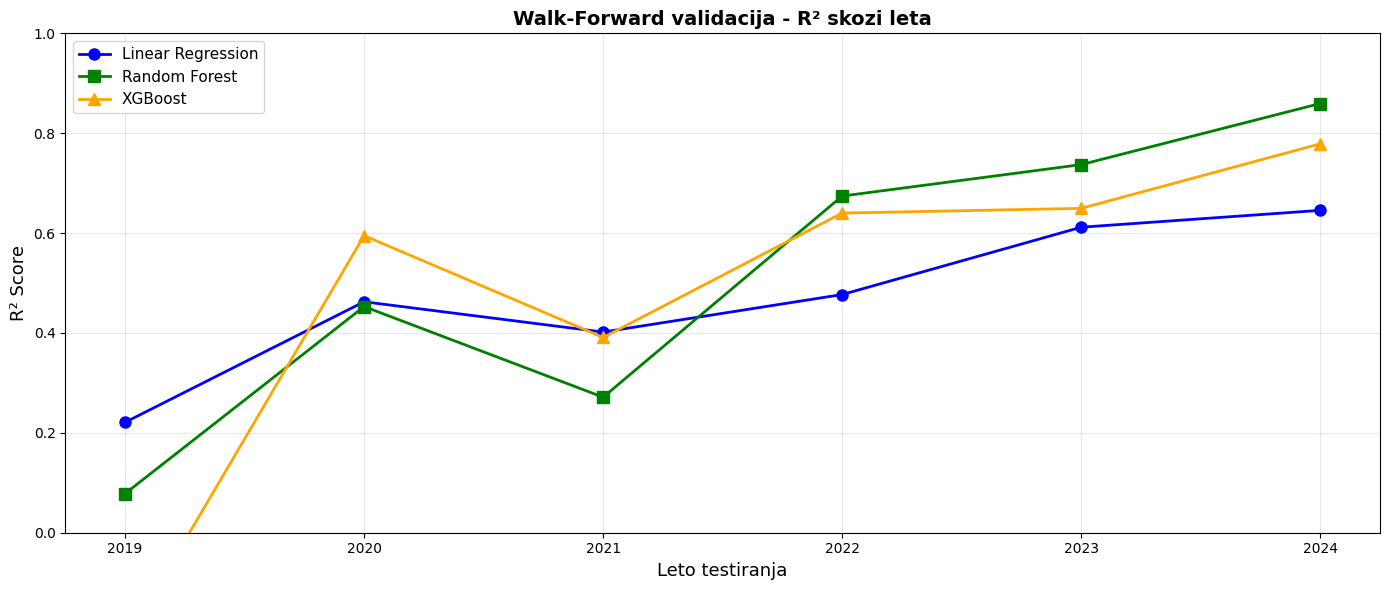

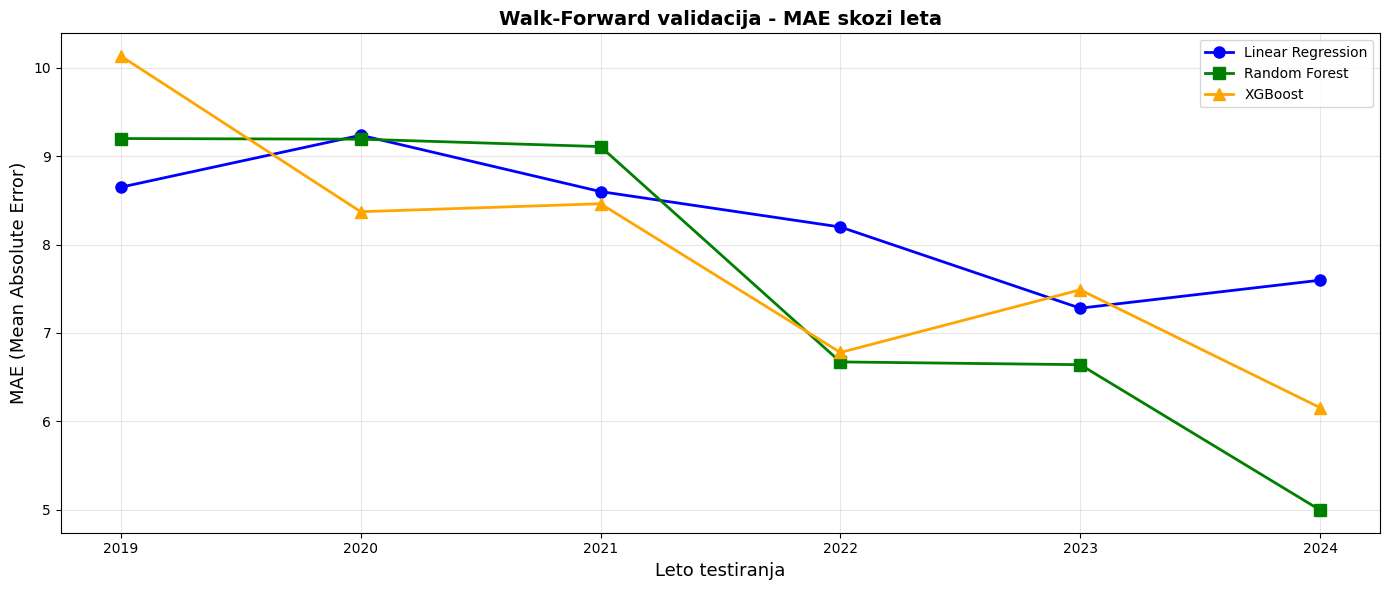

In [490]:
plt.figure(figsize=(14, 6))

plt.plot(df_oot['year'], df_oot['r2_lr'], marker='o', linewidth=2,
         markersize=8, label='Linear Regression', color='blue')
plt.plot(df_oot['year'], df_oot['r2_rf'], marker='s', linewidth=2,
         markersize=8, label='Random Forest', color='green')
plt.plot(df_oot['year'], df_oot['r2_xgb'], marker='^', linewidth=2,
         markersize=8, label='XGBoost', color='orange')


plt.xlabel('Leto testiranja', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.title('Walk-Forward validacija - R² skozi leta', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt. xticks(df_oot['year'])

plt.tight_layout()
plt.savefig('regresija_walk_forward_r2.png', dpi=150)
plt.show()



plt. figure(figsize=(14, 6))

plt.plot(df_oot['year'], df_oot['mae_lr'], marker='o', linewidth=2,
         markersize=8, label='Linear Regression', color='blue')
plt.plot(df_oot['year'], df_oot['mae_rf'], marker='s', linewidth=2,
         markersize=8, label='Random Forest', color='green')
plt.plot(df_oot['year'], df_oot['mae_xgb'], marker='^', linewidth=2,
         markersize=8, label='XGBoost', color='orange')



plt.xlabel('Leto testiranja', fontsize=13)
plt.ylabel('MAE (Mean Absolute Error)', fontsize=13)
plt.title('Walk-Forward validacija - MAE skozi leta', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt. xticks(df_oot['year'])

plt.tight_layout()
plt.savefig('regresija_walk_forward_mae.png', dpi=150)
plt.show()


MAE (povprečna napaka) pada skozi leta za vse tri modele, kar dokazuje, da
večja učna množica (več zgodovinskih podatkov) omogoča boljše napovedi.

Zgodnja leta (2019-2021) imajo MAE ~9-10, medtem ko leto 2024 doseže MAE ~5-7.
Random Forest je najboljši na zadnjih letih (MAE = 5.0 v 2024), medtem ko je
XGBoost najbolj nestabilen z najslabšim MAE = 10.1 v letu 2019.


# 7. REZULTATI IN ANALIZA REZULTATOV

## 7. 1. Rezultati gručenja

### 7. 1. 1. Opis

### 7. 1. 2. Analiza

### 7. 1. 3. Ovrednotenje

## 7. 2. Rezultati klasifikacije

### 7. 2. 1. Opis

### 7. 2. 2. Analiza

### 7. 2. 3. Ovrednotenje

## 7. 3. Rezultati regresije

### 7. 3. 1. Opis

### 7. 3. 2. Analiza

### 7. 3. 3. Ovrednotenje